In [1]:
import os
os.getcwd()

'/Users/mashazhuravlova/Desktop/BAM Thesis/Python'

In [2]:
os.chdir('/Users/mashazhuravlova/Desktop/BAM Thesis/Python')
os.getcwd()

'/Users/mashazhuravlova/Desktop/BAM Thesis/Python'

In [3]:
import os
os.listdir()

['meta_Amazon_Fashion.jsonl',
 'credibility_over_time_full.png',
 'Amazon_Fashion.jsonl',
 'meta_clean.csv',
 'analysis_code_650614.ipynb',
 'item_metadata.csv',
 'credibility_exploration.png',
 'user_reviews.csv',
 'Amazon_Fashion.csv.gz',
 'Thesis1.ipynb',
 '.ipynb_checkpoints',
 'filename.csv',
 'conceptual_model.png']

In [4]:
!pip install vaderSentiment

In [5]:
#Define a “pretty print” function pprint for dict objects and dataframes.

In [6]:
import json 
pprint = lambda x: print(json.dumps(x, indent=2)) if isinstance(x, dict) else display(x)

In [7]:
#Load User Reviews.
#rating: Rating of the product (from 1.0 to 5.0).
#title: Title of the user review.
#text: Text body of the user review.
#images: Images that users post after they have received the product.
#asin: ID of the product.
#parent_asin: Parent ID of the product. Note: Products with different colors, styles, sizes usually belong to the same parent ID. 
#user_id: ID of the reviewer
#timestamp: Time of the review (unix time)
#verified_purchase: User purchase verification
#helpful_vote: Helpful votes of the review

In [8]:
user_reviews = "Amazon_Fashion.jsonl"

In [9]:
with open(user_reviews, 'r') as fp:
    for line in fp:
        pprint(json.loads(line.strip()))
        break

{
  "rating": 5.0,
  "title": "Pretty locket",
  "text": "I think this locket is really pretty. The inside back is a solid silver depression and the front is a dome that is not solid (knotted). You could use it to store a small photo, lock of hair, etc but I use it when I need to carry medication with me. Closes securely. High quality & very pretty.",
  "images": [],
  "asin": "B00LOPVX74",
  "parent_asin": "B00LOPVX74",
  "user_id": "AGBFYI2DDIKXC5Y4FARTYDTQBMFQ",
  "timestamp": 1578528394489,
  "helpful_vote": 3,
  "verified_purchase": true
}


In [10]:
pip install "numpy<2.0" --upgrade

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd

chunks = []
chunksize = 100_000  # safe for my computer

for chunk in pd.read_json(
    "Amazon_Fashion.jsonl",
    lines=True,
    chunksize=chunksize
):
    # convert unix timestamp → datetime
    # the column is renamed: timestamp → date
    chunk["date"] = pd.to_datetime(chunk["timestamp"], unit="ms")

    # filter by year, I only need data from years 2014-2023
    chunk = chunk[(chunk["date"].dt.year >= 2014) & 
                  (chunk["date"].dt.year <= 2023)]

    chunks.append(chunk)

# final dataset (only 2014–2023)
user_reviews = pd.concat(chunks, ignore_index=True)
import pandas as pd

total_rows_before = 0
total_rows_after = 0

chunksize = 100_000

for chunk in pd.read_json(
    "Amazon_Fashion.jsonl",
    lines=True,
    chunksize=chunksize
):
    # count rows before filtering
    total_rows_before += len(chunk)

    # convert timestamp
    chunk['date'] = pd.to_datetime(chunk['timestamp'], unit='ms')

    # filter years
    chunk_filtered = chunk[
        (chunk['date'].dt.year >= 2014) &
        (chunk['date'].dt.year <= 2023)
    ]

    # count rows after filtering
    total_rows_after += len(chunk_filtered)

print("Rows BEFORE filtering:", total_rows_before)
print("Rows AFTER filtering (2014–2023):", total_rows_after)

user_reviews.shape

Rows BEFORE filtering: 2500939
Rows AFTER filtering (2014–2023): 2461982


(2461982, 11)

In [12]:
user_reviews.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,date
0,5,Pretty locket,I think this locket is really pretty. The insi...,[],B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2020-01-09 00:06:34.489,3,True,2020-01-09 00:06:34.489
1,5,A,Great,[],B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-20 01:04:06.701,0,True,2020-12-20 01:04:06.701
2,2,Two Stars,One of the stones fell out within the first 2 ...,[],B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-05-23 01:33:48.000,3,True,2015-05-23 01:33:48.000
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,[],B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2018-12-31 20:57:27.095,2,True,2018-12-31 20:57:27.095
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,[],B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-08-13 14:29:26.000,0,True,2015-08-13 14:29:26.000


In [13]:
#Check if the reviews are only within 2014-2023.

In [14]:
user_reviews["date"].dt.year.min(), user_reviews["date"].dt.year.max()

(2014, 2023)

In [15]:
#Check the data types.

In [16]:
user_reviews.dtypes

rating                        int64
title                        object
text                         object
images                       object
asin                         object
parent_asin                  object
user_id                      object
timestamp            datetime64[ns]
helpful_vote                  int64
verified_purchase              bool
date                 datetime64[ns]
dtype: object

In [17]:
#Check for empty/missing/duplicated values.

In [18]:
#NaNs per column
user_reviews.isna().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
date                 0
dtype: int64

In [19]:
#Empty string per text column
(user_reviews['text'] == "").sum()

692

In [20]:
#Empty string per title column
(user_reviews['title'] == "").sum()

0

In [21]:
#Empty title ad text reviews still contain valid star ratings, 
#helpful votes, and verified purchase share, that is why they are not removed.

In [22]:
#Check for duplicate reviews by user–product–time
user_reviews.duplicated(subset=['user_id', 'parent_asin', 'timestamp']).sum()

24822

In [23]:
#Inspect duplicates.
user_reviews.loc[
    user_reviews.duplicated(subset=['user_id', 'parent_asin', 'timestamp'], keep=False),
    ['user_id', 'parent_asin', 'timestamp', 'rating', 'title', 'text']
].sort_values(['user_id','parent_asin','timestamp']).head(50)

,user_id,parent_asin,timestamp,rating,title,text
695591,AE22CKN7DXMO7T5JNCDCSIGNRUQQ,B01ERXV1YY,2017-02-05 04:14:10.000,5,Cozy UGG Slippers,Love my UGG slippers. Nice snug fit. Also warm...
695592,AE22CKN7DXMO7T5JNCDCSIGNRUQQ,B01ERXV1YY,2017-02-05 04:14:10.000,5,Cozy UGG Slippers,Love my UGG slippers. Nice snug fit. Also warm...
415872,AE22E3XNIF5TITEAJXHT55LD5QUQ,B06XRDGMYK,2018-06-03 10:52:52.607,4,Comfortable. Do not recommend using it with a ...,Comfortable. Do not recommend using it with a ...
415873,AE22E3XNIF5TITEAJXHT55LD5QUQ,B06XRDGMYK,2018-06-03 10:52:52.607,4,Comfortable. Do not recommend using it with a ...,Comfortable. Do not recommend using it with a ...
2417831,AE22H7WQ4SONBVPSXEDPNPUFT73A,B00JRL2LAU,2017-12-31 17:21:50.918,2,They were not as comfortable as I was hoping e...,I got these to wear at my wedding and found ou...
2417832,AE22H7WQ4SONBVPSXEDPNPUFT73A,B00JRL2LAU,2017-12-31 17:21:50.918,2,They were not as comfortable as I was hoping e...,I got these to wear at my wedding and found ou...
2417833,AE22H7WQ4SONBVPSXEDPNPUFT73A,B00JRL2LAU,2017-12-31 17:21:50.918,2,They were not as comfortable as I was hoping e...,I got these to wear at my wedding and found ou...
2417834,AE22H7WQ4SONBVPSXEDPNPUFT73A,B00JRL2LAU,2017-12-31 17:21:50.918,2,They were not as comfortable as I was hoping e...,I got these to wear at my wedding and found ou...
2417837,AE22H7WQ4SONBVPSXEDPNPUFT73A,B00JRL2LAU,2017-12-31 17:21:50.918,2,They were not as comfortable as I was hoping e...,I got these to wear at my wedding and found ou...
1596452,AE22J6JO6BKIZXNDUCGF7SEP6VLA,B01KT026Q6,2017-07-26 18:25:24.586,3,Three Stars,I expected the material to be of a better quality


In [24]:
#Drop duplicated reviews and keep only the first occurrence of each duplicate review.
user_reviews = user_reviews.drop_duplicates(
    subset=['user_id', 'parent_asin', 'timestamp'],
    keep='first'
)

In [25]:
#Rating sanity checks.

In [26]:
user_reviews['rating'].describe()

count    2.437160e+06
mean     3.967034e+00
std      1.429215e+00
min      1.000000e+00
25%      3.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [27]:
user_reviews['rating'].value_counts().sort_index()

rating
1     297170
2     169421
3     239352
4     341856
5    1389361
Name: count, dtype: int64

In [28]:
#Time inspection.

In [29]:
#Check number of reviews per year.
user_reviews['date'].dt.year.value_counts().sort_index()

date
2014     59001
2015    126743
2016    285667
2017    368056
2018    366004
2019    408044
2020    309192
2021    306600
2022    172298
2023     35555
Name: count, dtype: int64

In [30]:
#Helpful votes inspection.
user_reviews['helpful_vote'].describe()

count    2.437160e+06
mean     5.527897e-01
std      3.654387e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.140000e+02
Name: helpful_vote, dtype: float64

In [31]:
#Proportion of verified/unverified purchases.
user_reviews['verified_purchase'].value_counts(normalize=True) * 100

verified_purchase
True     93.526605
False     6.473395
Name: proportion, dtype: float64

In [32]:
#Remove columns that are not needed for analysis. 

In [33]:
user_reviews = user_reviews.drop(columns=['images'])
user_reviews = user_reviews.drop(columns=['asin'])
user_reviews = user_reviews.drop(columns=['user_id'])
user_reviews = user_reviews.drop(columns=['timestamp'])

In [34]:
user_reviews.head()

,rating,title,text,parent_asin,helpful_vote,verified_purchase,date
0,5,Pretty locket,I think this locket is really pretty. The insi...,B00LOPVX74,3,True,2020-01-09 00:06:34.489
1,5,A,Great,B07B4JXK8D,0,True,2020-12-20 01:04:06.701
2,2,Two Stars,One of the stones fell out within the first 2 ...,B007ZSEQ4Q,3,True,2015-05-23 01:33:48.000
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,B07F2BTFS9,2,True,2018-12-31 20:57:27.095
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,B00XESJTDE,0,True,2015-08-13 14:29:26.000


In [35]:
#Only rating, title, text, parent_asin, helpful_vote, verified_purchase, and date are relevant to the analysis.

In [36]:
user_reviews.shape

(2437160, 7)

In [37]:
#Export user_reviews data frame as a csv file.

In [38]:
user_reviews.to_csv("user_reviews.csv", index=False)

In [39]:
#Create a working copy of user_reviews.

In [40]:
user_reviews_pn=user_reviews.copy()

In [41]:
#Convert date column to a "year-month" format, which allows for aggregating reviews by month.

In [42]:
user_reviews_pn['year_month'] = user_reviews_pn['date'].dt.to_period('M')

In [43]:
user_reviews_pn.head()

,rating,title,text,parent_asin,helpful_vote,verified_purchase,date,year_month
0,5,Pretty locket,I think this locket is really pretty. The insi...,B00LOPVX74,3,True,2020-01-09 00:06:34.489,2020-01
1,5,A,Great,B07B4JXK8D,0,True,2020-12-20 01:04:06.701,2020-12
2,2,Two Stars,One of the stones fell out within the first 2 ...,B007ZSEQ4Q,3,True,2015-05-23 01:33:48.000,2015-05
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,B07F2BTFS9,2,True,2018-12-31 20:57:27.095,2018-12
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,B00XESJTDE,0,True,2015-08-13 14:29:26.000,2015-08


In [44]:
# Create a single text field per review.

In [45]:
#Create full_text column for sentiment analysis.
#Full text= title of the review + text of the review
user_reviews_pn['full_text'] = (
    user_reviews_pn['title'].fillna("") + " " + user_reviews_pn['text'].fillna("")
).str.strip()

In [46]:
# Calculate word count for each individual review.
user_reviews_pn['review_word_count'] = user_reviews_pn['full_text'].str.split().str.len()

In [47]:
user_reviews_pn.head()

,rating,title,text,parent_asin,helpful_vote,verified_purchase,date,year_month,full_text,review_word_count
0,5,Pretty locket,I think this locket is really pretty. The insi...,B00LOPVX74,3,True,2020-01-09 00:06:34.489,2020-01,Pretty locket I think this locket is really pr...,60
1,5,A,Great,B07B4JXK8D,0,True,2020-12-20 01:04:06.701,2020-12,A Great,2
2,2,Two Stars,One of the stones fell out within the first 2 ...,B007ZSEQ4Q,3,True,2015-05-23 01:33:48.000,2015-05,Two Stars One of the stones fell out within th...,20
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,B07F2BTFS9,2,True,2018-12-31 20:57:27.095,2018-12,Won’t buy again Crappy socks. Money wasted. Bo...,18
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,B00XESJTDE,0,True,2015-08-13 14:29:26.000,2015-08,I LOVE these glasses I LOVE these glasses! Th...,60


In [48]:
#Create a unit of analysis: product*month.

In [49]:
#Create an aggregated product-month dataset with the following features:
#n_reviews, avg_review_length,avg_rating,avg_helpful,verified_share
user_reviews_pn_agg = (
    user_reviews_pn
    .groupby(['parent_asin', 'year_month'])
    .agg(
        n_reviews=('rating', 'count'),
        avg_review_length=('review_word_count', 'mean'),
        avg_rating=('rating', 'mean'),
        avg_helpful=('helpful_vote', 'mean'),
        verified_share=('verified_purchase', 'mean')
    )
    .reset_index()
)
#Round average review length to 0 decimal places (whole words)
user_reviews_pn_agg['avg_review_length'] = user_reviews_pn_agg['avg_review_length'].round(0)
#Rounding average rating, average helpful vote, verified purchase share to 2 decimal places
user_reviews_pn_agg['avg_rating'] = user_reviews_pn_agg['avg_rating'].round(2)
user_reviews_pn_agg['avg_helpful'] = user_reviews_pn_agg['avg_helpful'].round(2)
user_reviews_pn_agg['verified_share'] = user_reviews_pn_agg['verified_share'].round(2)

In [50]:
user_reviews_pn_agg.head()

,parent_asin,year_month,n_reviews,avg_review_length,avg_rating,avg_helpful,verified_share
0,0000099813,2019-11,1,35.0,5.0,0.0,1.0
1,0000099813,2020-01,2,88.0,5.0,0.0,0.5
2,0512238944,2022-05,1,8.0,5.0,0.0,1.0
3,0512238944,2022-06,1,14.0,5.0,0.0,0.0
4,0512238987,2022-10,1,66.0,3.0,0.0,0.0


In [51]:
#Prepare aggregated data for modelling

#Convert year_month to datetime
user_reviews_pn_agg['year_month'] = pd.to_datetime(
    user_reviews_pn_agg['year_month'].astype(str)
)

#Clean parent_asin
user_reviews_pn_agg['parent_asin'] = (
    user_reviews_pn_agg['parent_asin']
    .astype(str)
    .str.strip()
    .str.upper()
)

#Sort chronologically within each product
user_reviews_pn_agg = user_reviews_pn_agg.sort_values(
    ['parent_asin', 'year_month']
)

#Create next month date and measure gap
user_reviews_pn_agg['next_month_date'] = (
    user_reviews_pn_agg
    .groupby('parent_asin')['year_month']
    .shift(-1)
)
user_reviews_pn_agg['days_diff'] = (
    user_reviews_pn_agg['next_month_date'] - 
    user_reviews_pn_agg['year_month']
).dt.days

#Filter: minimum 5 reviews and consecutive months
#days_diff between 28-31 ensures consecutive calendar months
final_model_data = user_reviews_pn_agg[
    (user_reviews_pn_agg['n_reviews'] >= 5) & 
    (user_reviews_pn_agg['days_diff'] >= 28) & 
    (user_reviews_pn_agg['days_diff'] <= 31)
].copy()

#Create lag variable
#shift(1) brings previous month's review count into current row
final_model_data = final_model_data.sort_values(['parent_asin', 'year_month'])
final_model_data['n_reviews_lag1'] = (
    final_model_data
    .groupby('parent_asin')['n_reviews']
    .shift(1)
)

#Fill NaN for first observation of each product
#Use product-specific median as imputation value
product_medians = final_model_data.groupby('parent_asin')['n_reviews'].transform('median')
final_model_data['n_reviews_lag1'] = final_model_data['n_reviews_lag1'].fillna(product_medians)

#Remove singletons
#Products with only one observation cannot contribute to lead-lag analysis
before = final_model_data['parent_asin'].nunique()
product_counts = final_model_data.groupby('parent_asin').size()
valid_products = product_counts[product_counts > 1].index
final_model_data = final_model_data[
    final_model_data['parent_asin'].isin(valid_products)
].copy()
after = final_model_data['parent_asin'].nunique()

#Verify
print(f"Total rows: {len(final_model_data)}")
print(f"Unique products: {final_model_data['parent_asin'].nunique()}")
print(f"Singletons removed: {before - after} products")
print(f"\nDate range: {final_model_data['year_month'].min()} to {final_model_data['year_month'].max()}")
print(f"\nSample:")
print(final_model_data[['parent_asin', 'year_month', 'n_reviews', 'n_reviews_lag1']].head(10))

Total rows: 26606
Unique products: 4351
Singletons removed: 4637 products

Date range: 2014-01-01 00:00:00 to 2023-07-01 00:00:00

Sample:
     parent_asin year_month  n_reviews  n_reviews_lag1
71    0629150591 2016-05-01          6             7.0
72    0629150591 2016-06-01          7             6.0
73    0629150591 2016-07-01          7             7.0
74    0629150591 2016-08-01          7             7.0
76    0629150591 2016-10-01          5             7.0
1146  B0007MV6PO 2014-07-01          7             6.0
1152  B0007MV6PO 2015-06-01          5             7.0
1597  B000EB3RXM 2014-11-01          6             5.5
1598  B000EB3RXM 2014-12-01          6             6.0
1599  B000EB3RXM 2015-01-01          5             6.0


In [52]:
final_model_data.head()

,parent_asin,year_month,n_reviews,avg_review_length,avg_rating,avg_helpful,verified_share,next_month_date,days_diff,n_reviews_lag1
71,0629150591,2016-05-01,6,58.0,3.17,7.00,1.0,2016-06-01,31.0,7.0
72,0629150591,2016-06-01,7,13.0,3.71,1.43,1.0,2016-07-01,30.0,6.0
73,0629150591,2016-07-01,7,20.0,4.86,0.00,1.0,2016-08-01,31.0,7.0
74,0629150591,2016-08-01,7,23.0,4.43,0.00,1.0,2016-09-01,31.0,7.0
76,0629150591,2016-10-01,5,13.0,5.00,0.00,1.0,2016-11-01,31.0,7.0


In [53]:
#Verify again
product_counts = final_model_data.groupby('parent_asin').size()
#Identify products with only 1 month (Singletons)
singletons = product_counts[product_counts < 2].index
print(singletons)

Index([], dtype='object', name='parent_asin')


In [54]:
#Filter out the singletons by keeping only those NOT in the singletons list
final_model_data = final_model_data[~final_model_data['parent_asin'].isin(singletons)].copy()

#Final verification
print(f"Rows after singleton removal: {len(final_model_data)}")
print(f"Unique products remaining: {final_model_data['parent_asin'].nunique()}")

#Quick check: The minimum count per product should now be 2
print("\nMinimum observations per product:")
print(final_model_data.groupby('parent_asin').size().min())

Rows after singleton removal: 26606
Unique products remaining: 4351

Minimum observations per product:
2


In [55]:
#ENGINEERED FEATURE #1:
#Sort the dataframe to ensure the expansion is chronological
final_model_data = final_model_data.sort_values(['parent_asin', 'year_month'])

#Use a groupby and expanding sum to get the total reviews up to that month
final_model_data['cumulative_reviews'] = (
    final_model_data.groupby('parent_asin')['n_reviews']
    .expanding()
    .sum()
    .reset_index(level=0, drop=True)
)

#Shift to compute 'Cumulative Reviews prior to this month'
final_model_data['cumulative_reviews_prior'] = (
    final_model_data.groupby('parent_asin')['cumulative_reviews'].shift(1).fillna(0)
)

#List of columns I want as whole numbers
cols_to_fix = ['n_reviews', 'avg_review_length', 'n_reviews_lag1', 'cumulative_reviews', 'cumulative_reviews_prior']

#Convert them to integer
final_model_data[cols_to_fix] = final_model_data[cols_to_fix].fillna(0).astype(int)

In [56]:
final_model_data.head()

,parent_asin,year_month,n_reviews,avg_review_length,avg_rating,avg_helpful,verified_share,next_month_date,days_diff,n_reviews_lag1,cumulative_reviews,cumulative_reviews_prior
71,0629150591,2016-05-01,6,58,3.17,7.00,1.0,2016-06-01,31.0,7,6,0
72,0629150591,2016-06-01,7,13,3.71,1.43,1.0,2016-07-01,30.0,6,13,6
73,0629150591,2016-07-01,7,20,4.86,0.00,1.0,2016-08-01,31.0,7,20,13
74,0629150591,2016-08-01,7,23,4.43,0.00,1.0,2016-09-01,31.0,7,27,20
76,0629150591,2016-10-01,5,13,5.00,0.00,1.0,2016-11-01,31.0,7,32,27


In [57]:
final_model_data.shape

(26606, 12)

In [58]:
unique_products_count = final_model_data['parent_asin'].nunique()
print(f"Number of unique products in final dataset: {unique_products_count}")

Number of unique products in final dataset: 4351


In [59]:
final_model_data['n_reviews'].describe()

count    26606.000000
mean        10.551379
std         11.401948
min          5.000000
25%          5.000000
50%          7.000000
75%         11.000000
max        255.000000
Name: n_reviews, dtype: float64

In [60]:
final_model_data['n_reviews'].value_counts().head()

n_reviews
5    6735
6    4486
7    3234
8    2328
9    1712
Name: count, dtype: int64

In [61]:
#Load Item Metadata.
#main_category: Main category (i.e., domain) of the product.
#title: Name of the product.
#average_rating: Rating of the product shown on the product page.
#rating_number: Number of ratings in the product.
#features: Bullet-point format features of the product.
#description: Description of the product.
#price: Price in US dollars (at time of crawling).
#images:Images of the product.
#videos: Videos of the product including title and url.
#store: Store name of the product.
#categories: Hierarchical categories of the product.
#details: Product details, including materials, brand, sizes, etc.
#parent_asin: Parent ID of the product.
#bought_together: Recommended bundles from the websites.

In [62]:
item_metadata = "meta_Amazon_Fashion.jsonl"

In [63]:
with open(item_metadata, 'r') as fp:
    for line in fp:
        pprint(json.loads(line.strip()))
        break

{
  "main_category": "AMAZON FASHION",
  "title": "YUEDGE 5 Pairs Men's Moisture Control Cushioned Dry Fit Casual Athletic Crew Socks for Men (Blue, Size 9-12)",
  "average_rating": 4.6,
  "rating_number": 16,
  "features": [],
  "description": [],
  "price": null,
  "images": [
    {
      "thumb": "https://m.media-amazon.com/images/I/41+cCfaVOFS._AC_SR38,50_.jpg",
      "large": "https://m.media-amazon.com/images/I/41+cCfaVOFS._AC_.jpg",
      "variant": "MAIN",
      "hi_res": "https://m.media-amazon.com/images/I/81XlFXImFrS._AC_UL1500_.jpg"
    },
    {
      "thumb": "https://m.media-amazon.com/images/I/41jBdP7etRS._AC_SR38,50_.jpg",
      "large": "https://m.media-amazon.com/images/I/41jBdP7etRS._AC_.jpg",
      "variant": "PT01",
      "hi_res": "https://m.media-amazon.com/images/I/61+yVkHHQ3S._AC_UL1200_.jpg"
    },
    {
      "thumb": "https://m.media-amazon.com/images/I/41UGJiRe7UL._AC_SR38,50_.jpg",
      "large": "https://m.media-amazon.com/images/I/41UGJiRe7UL._AC_.jpg",


In [64]:
sum(1 for _ in open("meta_Amazon_Fashion.jsonl"))

826108

In [65]:
#Extract the parent ASINs that appear in years 2014-2023.

In [66]:
valid_parent_asins = user_reviews["parent_asin"].unique()

In [67]:
meta_chunks = []

for chunk in pd.read_json(
    "meta_Amazon_Fashion.jsonl",
    lines=True,
    chunksize=100_000
):
    chunk = chunk[chunk["parent_asin"].isin(valid_parent_asins)]
    meta_chunks.append(chunk)

item_metadata = pd.concat(meta_chunks, ignore_index=True)

item_metadata.shape

(816462, 14)

In [68]:
item_metadata.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,[],{'Package Dimensions': '10.31 x 8.5 x 1.73 inc...,B08BHN9PK5,NaN
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,[],{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,NaN
2,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B077KJHCJ4,NaN
3,AMAZON FASHION,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,29.81,[{'thumb': 'https://m.media-amazon.com/images/...,[],Guy Harvey,[],{'Package Dimensions': '11.22 x 4.72 x 4.33 in...,B0811M2JG9,NaN
4,AMAZON FASHION,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,17.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,RONNOX,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B07SB2892S,NaN


In [69]:
#Check the data types.

In [70]:
item_metadata.dtypes

main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together    float64
dtype: object

In [71]:
#Check for empty/missing/duplicated values.

In [72]:
#NaNs per column
item_metadata.isna().sum()

main_category           0
title                   0
average_rating          0
rating_number           0
features                0
description             0
price              766678
images                  0
videos                  0
store               25871
categories              0
details                 0
parent_asin             0
bought_together    816462
dtype: int64

In [73]:
#Check for duplicates in parent_asin.
item_metadata['parent_asin'].duplicated().sum()

0

In [74]:
#Create a clean metadata table where only paren_asin and store columns are kept.

In [75]:
meta_clean = item_metadata[['parent_asin', 'store']].copy()
meta_clean.head()

,parent_asin,store
0,B08BHN9PK5,GiveGift
1,B08R39MRDW,DouBCQ
2,B077KJHCJ4,Pastel by Vivienne
3,B0811M2JG9,Guy Harvey
4,B07SB2892S,RONNOX


In [76]:
meta_clean.shape

(816462, 2)

In [77]:
#Missing values per store column.
meta_clean['store'].isna().sum()

25871

In [78]:
#Empty strings per store column.
(meta_clean['store'] == "").sum()

3

In [79]:
#Count "Unknown" stores
(item_metadata['store'] == "Unknown").sum()

793

In [80]:
#Replace empty strings
meta_clean['store'] = meta_clean['store'].replace("", "Unknown")

In [81]:
# replace NaNs
meta_clean['store'] = meta_clean['store'].fillna("Unknown")

In [82]:
#Unknown stores before + Unknown converted from empty strings and NaNs.
(meta_clean['store'] == "Unknown").sum()

26667

In [83]:
#Verify that there are no missing values anymore.
print(meta_clean.isna().sum())

parent_asin    0
store          0
dtype: int64


In [84]:
meta_clean.to_csv("meta_clean.csv", index=False)

In [85]:
store_counts = meta_clean['store'].value_counts()
store_counts.head(10)

store
Unknown        26667
Nike            5024
Romwe           4150
GRACE KARIN     3832
Verdusa         3723
Floerns         3438
SheIn           3065
Disney          2829
Ekouaer         2763
SweatyRocks     2661
Name: count, dtype: int64

In [86]:
#Export item_metadata data frame as a csv file.

In [87]:
item_metadata.to_csv("item_metadata.csv", index=False)

In [88]:
#Prepare a clean metadata subset with only necessary columns.
meta_subset = item_metadata[['parent_asin', 'store']].copy()

#Drop duplicates in metadata to ensure a 1-to-1 or many-to-1 match
meta_subset = meta_subset.drop_duplicates(subset='parent_asin')

#Perform a clean left merge
#This adds 'store' to the model data based on the unique product ID
final_model_data = final_model_data.merge(meta_subset, on='parent_asin', how='left')

final_model_data.head(10)

,parent_asin,year_month,n_reviews,avg_review_length,avg_rating,avg_helpful,verified_share,next_month_date,days_diff,n_reviews_lag1,cumulative_reviews,cumulative_reviews_prior,store
0,0629150591,2016-05-01,6,58,3.17,7.00,1.00,2016-06-01,31.0,7,6,0,Jzcky Shzrp
1,0629150591,2016-06-01,7,13,3.71,1.43,1.00,2016-07-01,30.0,6,13,6,Jzcky Shzrp
2,0629150591,2016-07-01,7,20,4.86,0.00,1.00,2016-08-01,31.0,7,20,13,Jzcky Shzrp
3,0629150591,2016-08-01,7,23,4.43,0.00,1.00,2016-09-01,31.0,7,27,20,Jzcky Shzrp
4,0629150591,2016-10-01,5,13,5.00,0.00,1.00,2016-11-01,31.0,7,32,27,Jzcky Shzrp
5,B0007MV6PO,2014-07-01,7,43,4.57,0.57,0.71,2014-08-01,31.0,6,7,0,Henschel Hats
6,B0007MV6PO,2015-06-01,5,31,4.80,0.60,1.00,2015-07-01,30.0,7,12,7,Henschel Hats
7,B000EB3RXM,2014-11-01,6,36,2.50,0.33,1.00,2014-12-01,30.0,5,6,0,Marshal Wallet
8,B000EB3RXM,2014-12-01,6,38,3.00,0.17,1.00,2015-01-01,31.0,6,12,6,Marshal Wallet
9,B000EB3RXM,2015-01-01,5,10,5.00,0.00,1.00,2015-02-01,31.0,6,17,12,Marshal Wallet


In [89]:
print(final_model_data['store'].isna().sum())

574


In [90]:
#After merge: catch products with no metadata at all 
#Fill NAs with Unknown

final_model_data['store'] = final_model_data['store'].fillna("Unknown")

In [91]:
#Verify: should be 0
print(final_model_data['store'].isna().sum())

0


In [92]:
#Count the number of 'Unknown' stores.
(final_model_data['store'] == "Unknown").sum()

607

In [93]:
final_model_data.shape

(26606, 13)

In [94]:
#Check if there are missing/empty text reviews.

#Check for NaN text
nan_text = user_reviews_pn['full_text'].isna().sum()
print(f"NaN text reviews: {nan_text}")

#Check for empty string text
empty_text = (user_reviews_pn['full_text'] == "").sum()
print(f"Empty string text reviews: {empty_text}")

#Check for whitespace-only text
whitespace_text = (user_reviews_pn['full_text'].str.strip() == "").sum()
print(f"Whitespace-only text reviews: {whitespace_text}")

#Total problematic reviews
total_problematic = user_reviews_pn['full_text'].isna().sum() + \
                    (user_reviews_pn['full_text'].str.strip() == "").sum()
print(f"Total empty/missing text reviews: {total_problematic}")

NaN text reviews: 0
Empty string text reviews: 0
Whitespace-only text reviews: 0
Total empty/missing text reviews: 0


In [95]:
#Sentiment analysis
import sys
!{sys.executable} -m pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
print("Success! VADER is ready.")

Success! VADER is ready.


In [96]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

#Initialize the analyzer
analyzer = SentimentIntensityAnalyzer()

#Define a function to get the compound score
def get_vader_sentiment(text):
    if pd.isna(text) or text == "":
       return 0  
    return analyzer.polarity_scores(text)['compound']

#Apply to the raw reviews dataframe (this might take a few minutes)
user_reviews_pn['sentiment_score'] = user_reviews_pn['full_text'].apply(get_vader_sentiment)

In [97]:
user_reviews_pn.head()

,rating,title,text,parent_asin,helpful_vote,verified_purchase,date,year_month,full_text,review_word_count,sentiment_score
0,5,Pretty locket,I think this locket is really pretty. The insi...,B00LOPVX74,3,True,2020-01-09 00:06:34.489,2020-01,Pretty locket I think this locket is really pr...,60,0.8724
1,5,A,Great,B07B4JXK8D,0,True,2020-12-20 01:04:06.701,2020-12,A Great,2,0.6249
2,2,Two Stars,One of the stones fell out within the first 2 ...,B007ZSEQ4Q,3,True,2015-05-23 01:33:48.000,2015-05,Two Stars One of the stones fell out within th...,20,0.0000
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,B07F2BTFS9,2,True,2018-12-31 20:57:27.095,2018-12,Won’t buy again Crappy socks. Money wasted. Bo...,18,-0.6908
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,B00XESJTDE,0,True,2015-08-13 14:29:26.000,2015-08,I LOVE these glasses I LOVE these glasses! Th...,60,0.9793


In [98]:
#Sentiment aggregation

#Force timestamps
user_reviews_pn['year_month'] = pd.to_datetime(user_reviews_pn['year_month'].astype(str))
final_model_data['year_month'] = pd.to_datetime(final_model_data['year_month'].astype(str))

#Engineered feature #2.
#Aggregate sentiment and volatility at product-month level
monthly_sentiment = (
    user_reviews_pn
    .groupby(['parent_asin', 'year_month'])
    .agg(
        avg_sentiment=('sentiment_score', 'mean'),
        sentiment_volatility=('sentiment_score', 'std')
    )
    .reset_index()
)

#Handle single review case for volatility
# If only 1 review exists, std is undefined → fill with 0 (no disagreement)
monthly_sentiment['sentiment_volatility'] = monthly_sentiment['sentiment_volatility'].fillna(0)

#Drop existing columns if present (prevents duplicates)
for col in ['avg_sentiment', 'sentiment_volatility']:
    if col in final_model_data.columns:
        final_model_data = final_model_data.drop(columns=[col])

#Merge into final_model_data
final_model_data = final_model_data.merge(
    monthly_sentiment,
    on=['parent_asin', 'year_month'],
    how='left'
)

#Fill NaNs with 0 (safety fallback for unmatched product-months)
final_model_data['avg_sentiment'] = final_model_data['avg_sentiment'].fillna(0)
final_model_data['sentiment_volatility'] = final_model_data['sentiment_volatility'].fillna(0)

#Verify
print(final_model_data[['parent_asin', 'year_month', 
                          'avg_sentiment', 
                          'sentiment_volatility']].head(10))
print(f"\nNaN check:")
print(final_model_data[['avg_sentiment', 
                          'sentiment_volatility']].isna().sum())

  parent_asin year_month  avg_sentiment  sentiment_volatility
0  0629150591 2016-05-01       0.596717              0.562259
1  0629150591 2016-06-01       0.436886              0.335061
2  0629150591 2016-07-01       0.517243              0.559284
3  0629150591 2016-08-01       0.231371              0.388856
4  0629150591 2016-10-01       0.721940              0.131503
5  B0007MV6PO 2014-07-01       0.730929              0.264853
6  B0007MV6PO 2015-06-01       0.860660              0.122308
7  B000EB3RXM 2014-11-01      -0.177883              0.604753
8  B000EB3RXM 2014-12-01       0.237300              0.545638
9  B000EB3RXM 2015-01-01       0.532040              0.269214

NaN check:
avg_sentiment           0
sentiment_volatility    0
dtype: int64


In [99]:
final_model_data.head()

,parent_asin,year_month,n_reviews,avg_review_length,avg_rating,avg_helpful,verified_share,next_month_date,days_diff,n_reviews_lag1,cumulative_reviews,cumulative_reviews_prior,store,avg_sentiment,sentiment_volatility
0,0629150591,2016-05-01,6,58,3.17,7.00,1.0,2016-06-01,31.0,7,6,0,Jzcky Shzrp,0.596717,0.562259
1,0629150591,2016-06-01,7,13,3.71,1.43,1.0,2016-07-01,30.0,6,13,6,Jzcky Shzrp,0.436886,0.335061
2,0629150591,2016-07-01,7,20,4.86,0.00,1.0,2016-08-01,31.0,7,20,13,Jzcky Shzrp,0.517243,0.559284
3,0629150591,2016-08-01,7,23,4.43,0.00,1.0,2016-09-01,31.0,7,27,20,Jzcky Shzrp,0.231371,0.388856
4,0629150591,2016-10-01,5,13,5.00,0.00,1.0,2016-11-01,31.0,7,32,27,Jzcky Shzrp,0.721940,0.131503


In [100]:
#Normalization

#Normalize Star Rating to 0-1 scale
#Formula: (avg_rating - 1) / 4
#Maps: 1 star → 0, 5 stars → 1
final_model_data['norm_rating'] = (final_model_data['avg_rating'] - 1) / 4

#Normalize Sentiment Score to 0-1 scale
#Formula: (avg_sentiment + 1) / 2
#Maps: -1 (most negative) → 0, 0 (neutral) → 0.5, +1 (most positive) → 1
final_model_data['norm_sentiment'] = (final_model_data['avg_sentiment'] + 1) / 2

#ENGINEERED FEATURE #3
#Calculate Sentiment-Rating Gap
#Absolute difference between normalized rating and normalized sentiment
#High value = inconsistency between star rating and review text tone
final_model_data['sentiment_rating_gap'] = abs(
    final_model_data['norm_rating'] - final_model_data['norm_sentiment']
)

#ENGINEERED FEATURE #4
#Sentiment Change (momentum)
#First difference of avg_sentiment within each product time series
final_model_data = final_model_data.sort_values(['parent_asin', 'year_month'])
final_model_data['sentiment_change'] = (
    final_model_data
    .groupby('parent_asin')['avg_sentiment']
    .diff()
    .fillna(0)
)

#Verify
print(final_model_data[['parent_asin', 'avg_rating', 'norm_rating',
                          'avg_sentiment', 'norm_sentiment',
                          'sentiment_rating_gap',
                          'sentiment_change']].head(10))
print(f"\nNaN check:")
print(final_model_data[['norm_rating', 'norm_sentiment',
                          'sentiment_rating_gap',
                          'sentiment_change']].isna().sum())

  parent_asin  avg_rating  norm_rating  avg_sentiment  norm_sentiment  \
0  0629150591        3.17       0.5425       0.596717        0.798358   
1  0629150591        3.71       0.6775       0.436886        0.718443   
2  0629150591        4.86       0.9650       0.517243        0.758621   
3  0629150591        4.43       0.8575       0.231371        0.615686   
4  0629150591        5.00       1.0000       0.721940        0.860970   
5  B0007MV6PO        4.57       0.8925       0.730929        0.865464   
6  B0007MV6PO        4.80       0.9500       0.860660        0.930330   
7  B000EB3RXM        2.50       0.3750      -0.177883        0.411058   
8  B000EB3RXM        3.00       0.5000       0.237300        0.618650   
9  B000EB3RXM        5.00       1.0000       0.532040        0.766020   

   sentiment_rating_gap  sentiment_change  
0              0.255858          0.000000  
1              0.040943         -0.159831  
2              0.206379          0.080357  
3              0.241

In [101]:
#Engineered feature #5
#Verified Sentiment Signal (Authenticity)
# If verified_share is 1.0, the sentiment signal is "Full Strength"
final_model_data['verified_sentiment_signal'] = final_model_data['verified_share'] * final_model_data['avg_sentiment']

#Engineered feature #6
#Helpful Sentiment Impact (Reach/Salience)
# We add 1 to avg_helpful to avoid multiplying by 0 for new products
final_model_data['helpful_sentiment_impact'] = final_model_data['avg_sentiment'] * (final_model_data['avg_helpful'] + 1)

#Engineered feature #7
#High-Conflict Signal (Low Verified + High Rating)
# This flags potential "Review Manipulation" or "Cheap Talk"
final_model_data['unverified_hype'] = (1 - final_model_data['verified_share']) * final_model_data['avg_rating']

In [102]:
print(final_model_data[['avg_sentiment','norm_sentiment','norm_rating','sentiment_rating_gap', 'sentiment_change', 'verified_sentiment_signal','helpful_sentiment_impact','unverified_hype']])

       avg_sentiment  norm_sentiment  norm_rating  sentiment_rating_gap  \
0           0.596717        0.798358       0.5425              0.255858   
1           0.436886        0.718443       0.6775              0.040943   
2           0.517243        0.758621       0.9650              0.206379   
3           0.231371        0.615686       0.8575              0.241814   
4           0.721940        0.860970       1.0000              0.139030   
...              ...             ...          ...                   ...   
26601       0.766900        0.883450       1.0000              0.116550   
26602       0.732187        0.866094       0.9050              0.038906   
26603       0.628280        0.814140       1.0000              0.185860   
26604       0.818871        0.909436       0.8925              0.016936   
26605       0.180237        0.590119       0.6550              0.064881   

       sentiment_change  verified_sentiment_signal  helpful_sentiment_impact  \
0              0.00

In [103]:
#Drop unnecessary/intermidiate columns

columns_to_drop = [
    'next_month_date',
    'days_diff',
    'cumulative_reviews',
    'norm_rating',
    'norm_sentiment'
]
final_model_data2 = final_model_data.drop(columns=columns_to_drop)

#Verify
print(f"Remaining columns: {final_model_data2.shape[1]}")
print(final_model_data2.columns.tolist())

Remaining columns: 17
['parent_asin', 'year_month', 'n_reviews', 'avg_review_length', 'avg_rating', 'avg_helpful', 'verified_share', 'n_reviews_lag1', 'cumulative_reviews_prior', 'store', 'avg_sentiment', 'sentiment_volatility', 'sentiment_rating_gap', 'sentiment_change', 'verified_sentiment_signal', 'helpful_sentiment_impact', 'unverified_hype']


In [104]:
#Define the order of variables
col_order = [
    'parent_asin',
    'year_month',
    'n_reviews',
    'n_reviews_lag1',
    'cumulative_reviews_prior',
    'avg_rating',
    'avg_review_length',
    'avg_helpful',
    'verified_share',
    'avg_sentiment',
    'sentiment_volatility', 
    'sentiment_rating_gap', 
    'sentiment_change', 
    'verified_sentiment_signal', 
    'helpful_sentiment_impact', 
    'unverified_hype',
    'store'
]

final_model_data2 = final_model_data2[col_order]

print(final_model_data2.columns.tolist())

['parent_asin', 'year_month', 'n_reviews', 'n_reviews_lag1', 'cumulative_reviews_prior', 'avg_rating', 'avg_review_length', 'avg_helpful', 'verified_share', 'avg_sentiment', 'sentiment_volatility', 'sentiment_rating_gap', 'sentiment_change', 'verified_sentiment_signal', 'helpful_sentiment_impact', 'unverified_hype', 'store']


In [105]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Check all of the variables.
features_to_check = [
    'n_reviews_lag1','avg_rating', 'avg_sentiment', 'avg_helpful', 'sentiment_rating_gap',
    'verified_share','sentiment_change','verified_sentiment_signal', 
    'helpful_sentiment_impact', 'unverified_hype', 'sentiment_volatility', 'cumulative_reviews_prior', 'avg_review_length'
] #store is excluded from this list because it is needed only for Heterogeneity analysis

# Drop any NaNs just for the check
vif_data = final_model_data2[features_to_check].dropna()

# Calculate VIF for each feature
vif_results = pd.DataFrame()
vif_results["feature"] = features_to_check
vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_data.columns))]

print(vif_results.sort_values(by="VIF", ascending=False))

                      feature         VIF
2               avg_sentiment  584.165434
7   verified_sentiment_signal  533.452917
1                  avg_rating  110.935027
5              verified_share  103.870917
9             unverified_hype   25.191898
10       sentiment_volatility   14.086580
8    helpful_sentiment_impact   11.699329
3                 avg_helpful    8.134359
12          avg_review_length    5.317697
4        sentiment_rating_gap    3.169064
0              n_reviews_lag1    2.455649
11   cumulative_reviews_prior    1.470733
6            sentiment_change    1.376135


In [106]:
#Select only the core independent variables.
features_to_check = [
    'n_reviews_lag1','avg_rating', 'avg_sentiment', 
    'avg_helpful', 'verified_share'
]

#Drop any NaNs just for the check
vif_data = final_model_data2[features_to_check].dropna()

#Calculate VIF for each feature
vif_results = pd.DataFrame()
vif_results["feature"] = features_to_check
vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_data.columns))]

print(vif_results.sort_values(by="VIF", ascending=False))

          feature        VIF
1      avg_rating  50.620299
4  verified_share  21.610068
2   avg_sentiment  16.215138
0  n_reviews_lag1   1.875728
3     avg_helpful   1.120277


In [107]:
print(final_model_data2.isna().sum())

parent_asin                  0
year_month                   0
n_reviews                    0
n_reviews_lag1               0
cumulative_reviews_prior     0
avg_rating                   0
avg_review_length            0
avg_helpful                  0
verified_share               0
avg_sentiment                0
sentiment_volatility         0
sentiment_rating_gap         0
sentiment_change             0
verified_sentiment_signal    0
helpful_sentiment_impact     0
unverified_hype              0
store                        0
dtype: int64


In [108]:
#Feature set for regression models (Lasso, Ridge, Elastic Net)
#Core theoretically motivated predictors only (low VIF)
features_regression = [
    'n_reviews_lag1',
    'avg_rating',
    'avg_sentiment',
    'avg_helpful',
    'verified_share'
]

#Feature set for tree-based models (Random Forest, XGBoost)
#Full feature set: trees are not sensitive to multicollinearity
features_trees = [
    'n_reviews_lag1',
    'avg_rating',
    'avg_sentiment',
    'avg_helpful',
    'verified_share',
    'sentiment_rating_gap',
    'verified_sentiment_signal',
    'helpful_sentiment_impact',
    'unverified_hype',
    'sentiment_volatility',
    'sentiment_change',
    'cumulative_reviews_prior',
    'avg_review_length'
]

In [109]:
final_model_data2.groupby(final_model_data2['year_month'].dt.year)['parent_asin'].count()

year_month
2014    1088
2015    2276
2016    4503
2017    4198
2018    3001
2019    3151
2020    2754
2021    2700
2022    2265
2023     670
Name: parent_asin, dtype: int64

In [110]:
#Split the data: same for all model types
train = final_model_data2[final_model_data2['year_month'] <= '2019-12-01']
val   = final_model_data2[(final_model_data2['year_month'] >= '2020-01-01') & 
                           (final_model_data2['year_month'] <= '2021-12-01')]
test  = final_model_data2[final_model_data2['year_month'] >= '2022-01-01']

#Define target y 
y_train = train['n_reviews']
y_val   = val['n_reviews']
y_test  = test['n_reviews']

#Define features X: different feature sets
X_train_reg  = train[features_regression]
X_val_reg    = val[features_regression]
X_test_reg   = test[features_regression]

X_train_tree = train[features_trees]
X_val_tree   = val[features_trees]
X_test_tree  = test[features_trees]

print(f"Train size: {len(train)}")
print(f"Validation size: {len(val)}")
print(f"Test size: {len(test)}")

Train size: 18217
Validation size: 5454
Test size: 2935


In [111]:
#Verify no overlap between splits
print(f"Train: {train['year_month'].min().date()} to {train['year_month'].max().date()}")
print(f"Val:   {val['year_month'].min().date()} to {val['year_month'].max().date()}")
print(f"Test:  {test['year_month'].min().date()} to {test['year_month'].max().date()}")

#Verify no data leakage between splits
assert train['year_month'].max() < val['year_month'].min(), "Train/Val overlap detected!"
assert val['year_month'].max() < test['year_month'].min(), "Val/Test overlap detected!"
print("\nNo overlap detected between splits")

Train: 2014-01-01 to 2019-12-01
Val:   2020-01-01 to 2021-12-01
Test:  2022-01-01 to 2023-07-01

No overlap detected between splits


In [112]:
#Feature scaling only for regression models
from sklearn.preprocessing import StandardScaler

#Initialize scaler
scaler = StandardScaler()

#Fit only on training set, then, transform all three splits
#This prevents future information from influencing scaling parameters
X_train_scaled = scaler.fit_transform(X_train_reg)   # fit + transform
X_val_scaled   = scaler.transform(X_val_reg)          # transform only
X_test_scaled  = scaler.transform(X_test_reg)         # transform only

#Verify
#Check scaling parameters learned from training set
print("── Scaling Parameters (learned from training set only) ──")
scaling_info = pd.DataFrame({
    'Feature': features_regression,
    'Train Mean': scaler.mean_.round(4),
    'Train Std': scaler.scale_.round(4)
})
print(scaling_info.to_string(index=False))

#Verify scaled training data has mean ≈ 0 and std ≈ 1
print("\n── Scaled Training Data Statistics ──")
scaled_train_df = pd.DataFrame(X_train_scaled, columns=features_regression)
print(scaled_train_df.describe().round(4))

#Verify shapes
print(f"\n── Shape Verification ──")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

#Check for NaNs after scaling
print(f"\n── NaN Check ──")
print(f"Train NaNs: {pd.DataFrame(X_train_scaled).isna().sum().sum()}")
print(f"Val NaNs:   {pd.DataFrame(X_val_scaled).isna().sum().sum()}")
print(f"Test NaNs:  {pd.DataFrame(X_test_scaled).isna().sum().sum()}")

── Scaling Parameters (learned from training set only) ──
       Feature  Train Mean  Train Std
n_reviews_lag1      9.8945     9.8645
    avg_rating      4.0526     0.7148
 avg_sentiment      0.5597     0.2258
   avg_helpful      0.7235     2.1106
verified_share      0.9435     0.1337

── Scaled Training Data Statistics ──
       n_reviews_lag1  avg_rating  avg_sentiment  avg_helpful  verified_share
count      18217.0000  18217.0000     18217.0000   18217.0000      18217.0000
mean           0.0000      0.0000        -0.0000      -0.0000         -0.0000
std            1.0000      1.0000         1.0000       1.0000          1.0000
min           -0.4962     -4.2707        -5.2805      -0.3428         -7.0554
25%           -0.3948     -0.5353        -0.5682      -0.3428          0.0488
50%           -0.2934      0.2062         0.1510      -0.2575          0.4228
75%            0.0107      0.7659         0.7311      -0.0490          0.4228
max           19.5757      1.3255         1.8895   

In [113]:
#Helper function
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    return {'Model': name, 'MAE': round(mae, 4), 
            'RMSE': round(rmse, 4), 'R2': round(r2, 4)}

In [114]:
#Naive baseline: predict next month = last month
y_pred_baseline_val  = val['n_reviews_lag1']
y_pred_baseline_test = test['n_reviews_lag1']

print("── Naive Baseline (Validation) ──")
evaluate_model('Naive Baseline', y_val, y_pred_baseline_val)

print("── Naive Baseline (Test) ──")
evaluate_model('Naive Baseline', y_test, y_pred_baseline_test)

── Naive Baseline (Validation) ──

Naive Baseline
  MAE:  4.4430
  RMSE: 8.8186
  R²:   0.6301
── Naive Baseline (Test) ──

Naive Baseline
  MAE:  4.1165
  RMSE: 7.5429
  R²:   0.5407


{'Model': 'Naive Baseline', 'MAE': 4.1165, 'RMSE': 7.5429, 'R2': 0.5407}

In [115]:
#Regularized regression models
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

#Ridge
ridge_cv = RidgeCV(
    alphas=[0.01, 0.1, 1.0, 10.0, 100.0],
    cv=5
)
ridge_cv.fit(X_train_scaled, y_train)
print(f"Ridge best alpha: {ridge_cv.alpha_}")

#Lasso
lasso_cv = LassoCV(
    alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    cv=5,
    max_iter=10000,
    random_state=42
)
lasso_cv.fit(X_train_scaled, y_train)
print(f"Lasso best alpha: {lasso_cv.alpha_}")

#Elastic Net
enet_cv = ElasticNetCV(
    alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    cv=5,
    max_iter=10000,
    random_state=42
)
enet_cv.fit(X_train_scaled, y_train)
print(f"Elastic Net best alpha: {enet_cv.alpha_}")
print(f"Elastic Net best l1_ratio: {enet_cv.l1_ratio_}")

#Evaluation on validation set
print("\n── Regression Models — Validation Set ──")
reg_results_val = []
reg_results_val.append(evaluate_model(
    'Ridge (tuned)', y_val, ridge_cv.predict(X_val_scaled)))
reg_results_val.append(evaluate_model(
    'Lasso (tuned)', y_val, lasso_cv.predict(X_val_scaled)))
reg_results_val.append(evaluate_model(
    'Elastic Net (tuned)', y_val, enet_cv.predict(X_val_scaled)))

reg_val_df = pd.DataFrame(reg_results_val)
print("\n── Summary ──")
print(reg_val_df.to_string(index=False))

Ridge best alpha: 100.0
Lasso best alpha: 0.001
Elastic Net best alpha: 0.001
Elastic Net best l1_ratio: 0.9

── Regression Models — Validation Set ──

Ridge (tuned)
  MAE:  4.2254
  RMSE: 8.2579
  R²:   0.6757

Lasso (tuned)
  MAE:  4.2289
  RMSE: 8.2648
  R²:   0.6751

Elastic Net (tuned)
  MAE:  4.2288
  RMSE: 8.2647
  R²:   0.6751

── Summary ──
              Model    MAE   RMSE     R2
      Ridge (tuned) 4.2254 8.2579 0.6757
      Lasso (tuned) 4.2289 8.2648 0.6751
Elastic Net (tuned) 4.2288 8.2647 0.6751


In [116]:
#Lasso coefficients
lasso_coef = pd.DataFrame({
    'Feature': features_regression,
    'Coefficient': lasso_cv.coef_
})
lasso_coef['Abs_Coefficient'] = lasso_coef['Coefficient'].abs()
lasso_coef = lasso_coef.sort_values(by='Abs_Coefficient', ascending=False)

print("\n── Lasso Feature Coefficients ──")
print(lasso_coef[['Feature', 'Coefficient']].to_string(index=False))
print(f"\nFeatures zeroed out: {(lasso_coef['Coefficient'] == 0).sum()}")
print(f"Features retained:   {(lasso_coef['Coefficient'] != 0).sum()}")

#Ridge coefficients
ridge_coef = pd.DataFrame({
    'Feature': features_regression,
    'Coefficient': ridge_cv.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n── Ridge Feature Coefficients ──")
print(ridge_coef.to_string(index=False))
#Elastic Net coefficients
enet_coef = pd.DataFrame({
    'Feature': features_regression,
    'Coefficient': enet_cv.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n── Elastic Net Feature Coefficients ──")
print(enet_coef.to_string(index=False))
print(f"\nFeatures zeroed out: {(enet_coef['Coefficient'] == 0).sum()}")
print(f"Features retained:   {(enet_coef['Coefficient'] != 0).sum()}")


── Lasso Feature Coefficients ──
       Feature  Coefficient
n_reviews_lag1     8.359217
    avg_rating     0.205949
verified_share    -0.067133
   avg_helpful     0.028671
 avg_sentiment    -0.002112

Features zeroed out: 0
Features retained:   5

── Ridge Feature Coefficients ──
       Feature  Coefficient
n_reviews_lag1     8.314383
    avg_rating     0.210991
verified_share    -0.066653
   avg_helpful     0.028876
 avg_sentiment    -0.005607

── Elastic Net Feature Coefficients ──
       Feature  Coefficient
n_reviews_lag1     8.358472
    avg_rating     0.206401
verified_share    -0.067218
   avg_helpful     0.028773
 avg_sentiment    -0.002542

Features zeroed out: 0
Features retained:   5


In [117]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
rf_tuned.fit(X_train_tree, y_train)
print(f"\nRF best parameters: {rf_tuned.best_params_}")

#Validation Performance
print("\n── Random Forest — Validation Set ──")
rf_val = evaluate_model(
    'Random Forest (tuned)', 
    y_val, 
    rf_tuned.predict(X_val_tree)
)

#Feature Importance
rf_importance = pd.DataFrame({
    'Feature': features_trees,
    'Importance': rf_tuned.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n── Random Forest Feature Importance ──")
print(rf_importance.to_string(index=False))

#Cumulative Importance
rf_importance['Cumulative_Importance'] = rf_importance['Importance'].cumsum()
print("\n── Cumulative Feature Importance ──")
print(rf_importance[['Feature', 'Importance', 'Cumulative_Importance']].to_string(index=False))

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



RF best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}

── Random Forest — Validation Set ──

Random Forest (tuned)
  MAE:  3.5731
  RMSE: 7.3532
  R²:   0.7428

── Random Forest Feature Importance ──
                  Feature  Importance
           n_reviews_lag1    0.427124
 cumulative_reviews_prior    0.147732
          unverified_hype    0.085288
           verified_share    0.082012
              avg_helpful    0.045119
     sentiment_volatility    0.033079
               avg_rating    0.029985
verified_sentiment_signal    0.026725
            avg_sentiment    0.026219
 helpful_sentiment_impact    0.025742
     sentiment_rating_gap    0.025560
         sentiment_change    0.024644
        avg_review_length    0.020771

── Cumulative Feature Importance ──
                  Feature  Importance  Cumulative_Importance
           n_reviews_lag1    0.427124               0.427124
 cumulative_reviews_prior    0.147732               0.57

In [118]:
#XGBoost
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_tuned = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_xgb,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
xgb_tuned.fit(X_train_tree, y_train)
print(f"\nXGB best parameters: {xgb_tuned.best_params_}")

#Validation performance
print("\n── XGBoost — Validation Set ──")
xgb_val = evaluate_model(
    'XGBoost (tuned)',
    y_val,
    xgb_tuned.predict(X_val_tree)
)

#Feature importance
xgb_importance = pd.DataFrame({
    'Feature': features_trees,
    'Importance': xgb_tuned.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n── XGBoost Feature Importance ──")
print(xgb_importance.to_string(index=False))

#Cumulative importance
xgb_importance['Cumulative_Importance'] = xgb_importance['Importance'].cumsum()
print("\n── Cumulative Feature Importance ──")
print(xgb_importance[['Feature', 
                        'Importance', 
                        'Cumulative_Importance']].to_string(index=False))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

XGB best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}

── XGBoost — Validation Set ──

XGBoost (tuned)
  MAE:  4.0442
  RMSE: 9.3185
  R²:   0.5870

── XGBoost Feature Importance ──
                  Feature  Importance
           n_reviews_lag1    0.350155
 cumulative_reviews_prior    0.180353
           verified_share    0.134209
          unverified_hype    0.108223
              avg_helpful    0.041482
            avg_sentiment    0.040153
               avg_rating    0.027637
verified_sentiment_signal    0.026650
 helpful_sentiment_impact    0.025739
     sentiment_volatility    0.021136
         sentiment_change    0.017358
     sentiment_rating_gap    0.017354
        avg_review_length    0.009553

── Cumulative Feature Importance ──
                  Feature  Importance  Cumulative_Importance
           n_reviews_lag1    0.350155               

In [119]:
#All models comparison

#Validation set
val_results = []
val_results.append(evaluate_model(
    'Naive Baseline', y_val, val['n_reviews_lag1']))
val_results.append(evaluate_model(
    'Ridge (tuned)', y_val, ridge_cv.predict(X_val_scaled)))
val_results.append(evaluate_model(
    'Lasso (tuned)', y_val, lasso_cv.predict(X_val_scaled)))
val_results.append(evaluate_model(
    'Elastic Net (tuned)', y_val, enet_cv.predict(X_val_scaled)))
val_results.append(evaluate_model(
    'Random Forest (tuned)', y_val, rf_tuned.predict(X_val_tree)))
val_results.append(evaluate_model(
    'XGBoost (tuned)', y_val, xgb_tuned.predict(X_val_tree)))

val_df = pd.DataFrame(val_results)
print("\n── Validation Set Results ──")
print(val_df.to_string(index=False))

#Test set
test_results = []
test_results.append(evaluate_model(
    'Naive Baseline', y_test, test['n_reviews_lag1']))
test_results.append(evaluate_model(
    'Ridge (tuned)', y_test, ridge_cv.predict(X_test_scaled)))
test_results.append(evaluate_model(
    'Lasso (tuned)', y_test, lasso_cv.predict(X_test_scaled)))
test_results.append(evaluate_model(
    'Elastic Net (tuned)', y_test, enet_cv.predict(X_test_scaled)))
test_results.append(evaluate_model(
    'Random Forest (tuned)', y_test, rf_tuned.predict(X_test_tree)))
test_results.append(evaluate_model(
    'XGBoost (tuned)', y_test, xgb_tuned.predict(X_test_tree)))

test_df = pd.DataFrame(test_results)
print("\n── Test Set Results ──")
print(test_df.to_string(index=False))

#Improvement over baseline
baseline_mae  = test_df[test_df['Model'] == 'Naive Baseline']['MAE'].values[0]
baseline_rmse = test_df[test_df['Model'] == 'Naive Baseline']['RMSE'].values[0]

print("\n── Improvement Over Naive Baseline (Test Set) ──")
for _, row in test_df.iterrows():
    if row['Model'] != 'Naive Baseline':
        mae_imp  = ((baseline_mae - row['MAE']) / baseline_mae) * 100
        rmse_imp = ((baseline_rmse - row['RMSE']) / baseline_rmse) * 100
        print(f"{row['Model']:25s} MAE: {mae_imp:+.2f}%  RMSE: {rmse_imp:+.2f}%")

#Combined table
combined = val_df.merge(test_df, on='Model', suffixes=(' Val', ' Test'))
print("\n── Full Comparison Table ──")
print(combined.to_string(index=False))


Naive Baseline
  MAE:  4.4430
  RMSE: 8.8186
  R²:   0.6301

Ridge (tuned)
  MAE:  4.2254
  RMSE: 8.2579
  R²:   0.6757

Lasso (tuned)
  MAE:  4.2289
  RMSE: 8.2648
  R²:   0.6751

Elastic Net (tuned)
  MAE:  4.2288
  RMSE: 8.2647
  R²:   0.6751

Random Forest (tuned)
  MAE:  3.5731
  RMSE: 7.3532
  R²:   0.7428

XGBoost (tuned)
  MAE:  4.0442
  RMSE: 9.3185
  R²:   0.5870

── Validation Set Results ──
                Model    MAE   RMSE     R2
       Naive Baseline 4.4430 8.8186 0.6301
        Ridge (tuned) 4.2254 8.2579 0.6757
        Lasso (tuned) 4.2289 8.2648 0.6751
  Elastic Net (tuned) 4.2288 8.2647 0.6751
Random Forest (tuned) 3.5731 7.3532 0.7428
      XGBoost (tuned) 4.0442 9.3185 0.5870

Naive Baseline
  MAE:  4.1165
  RMSE: 7.5429
  R²:   0.5407

Ridge (tuned)
  MAE:  3.9048
  RMSE: 6.9787
  R²:   0.6069

Lasso (tuned)
  MAE:  3.9096
  RMSE: 6.9887
  R²:   0.6058

Elastic Net (tuned)
  MAE:  3.9095
  RMSE: 6.9885
  R²:   0.6058

Random Forest (tuned)
  MAE:  3.6289
  RMSE:

In [120]:
#XGBoost is massively overfitting.
#XGBoost with Early Stopping
xgb_early = XGBRegressor(
    n_estimators=1000,      # set high — early stopping will find optimal
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50  # stop if no improvement after 50 rounds
)

xgb_early.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],
    verbose=100
)

print(f"Best iteration: {xgb_early.best_iteration}")
print(f"Best validation score: {xgb_early.best_score}")

print("\n── XGBoost Early Stopping — Validation ──")
evaluate_model('XGBoost Early Stopping', y_val, xgb_early.predict(X_val_tree))

print("\n── XGBoost Early Stopping — Test ──")
evaluate_model('XGBoost Early Stopping', y_test, xgb_early.predict(X_test_tree))

[0]	validation_0-rmse:14.16502
[100]	validation_0-rmse:8.60058
[112]	validation_0-rmse:8.82619
Best iteration: 62
Best validation score: 7.853781270214277

── XGBoost Early Stopping — Validation ──

XGBoost Early Stopping
  MAE:  4.0722
  RMSE: 7.8538
  R²:   0.7066

── XGBoost Early Stopping — Test ──

XGBoost Early Stopping
  MAE:  4.0971
  RMSE: 6.9416
  R²:   0.6110


{'Model': 'XGBoost Early Stopping', 'MAE': 4.0971, 'RMSE': 6.9416, 'R2': 0.611}

In [121]:
#Feature importance
xgb_early_importance = pd.DataFrame({
    'Feature': features_trees,
    'Importance': xgb_early.feature_importances_  # removed .best_estimator_
}).sort_values(by='Importance', ascending=False)

print("\n── XGBoost Early Stopping Feature Importance ──")
print(xgb_early_importance.to_string(index=False))

#Cumulative importance
xgb_early_importance['Cumulative_Importance'] = xgb_early_importance['Importance'].cumsum()
print("\n── Cumulative Feature Importance ──")
print(xgb_early_importance[['Feature', 
                        'Importance', 
                        'Cumulative_Importance']].to_string(index=False))


── XGBoost Early Stopping Feature Importance ──
                  Feature  Importance
           n_reviews_lag1    0.347833
 cumulative_reviews_prior    0.201349
           verified_share    0.139914
          unverified_hype    0.101886
              avg_helpful    0.038322
            avg_sentiment    0.037533
               avg_rating    0.029810
verified_sentiment_signal    0.023732
 helpful_sentiment_impact    0.021001
         sentiment_change    0.018868
     sentiment_volatility    0.015398
     sentiment_rating_gap    0.013427
        avg_review_length    0.010928

── Cumulative Feature Importance ──
                  Feature  Importance  Cumulative_Importance
           n_reviews_lag1    0.347833               0.347833
 cumulative_reviews_prior    0.201349               0.549182
           verified_share    0.139914               0.689096
          unverified_hype    0.101886               0.790981
              avg_helpful    0.038322               0.829303
            avg_

In [122]:
#Final complete model comparison

test_results_final = []
test_results_final.append(evaluate_model(
    'Naive Baseline', y_test, test['n_reviews_lag1']))
test_results_final.append(evaluate_model(
    'Ridge (tuned)', y_test, ridge_cv.predict(X_test_scaled)))
test_results_final.append(evaluate_model(
    'Lasso (tuned)', y_test, lasso_cv.predict(X_test_scaled)))
test_results_final.append(evaluate_model(
    'Elastic Net (tuned)', y_test, enet_cv.predict(X_test_scaled)))
test_results_final.append(evaluate_model(
    'Random Forest (tuned)', y_test, rf_tuned.predict(X_test_tree)))
test_results_final.append(evaluate_model(
    'XGBoost Early Stopping', y_test, xgb_early.predict(X_test_tree)))

test_final_df = pd.DataFrame(test_results_final)
print("\n── Final Model Comparison (Test Set) ──")
print(test_final_df.to_string(index=False))

#Improvement over baseline
baseline_mae  = test_final_df[test_final_df['Model'] == 'Naive Baseline']['MAE'].values[0]
baseline_rmse = test_final_df[test_final_df['Model'] == 'Naive Baseline']['RMSE'].values[0]

print("\n── Improvement Over Naive Baseline ──")
for _, row in test_final_df.iterrows():
    if row['Model'] != 'Naive Baseline':
        mae_imp  = ((baseline_mae - row['MAE']) / baseline_mae) * 100
        rmse_imp = ((baseline_rmse - row['RMSE']) / baseline_rmse) * 100
        print(f"{row['Model']:25s} MAE: {mae_imp:+.2f}%  RMSE: {rmse_imp:+.2f}%")


Naive Baseline
  MAE:  4.1165
  RMSE: 7.5429
  R²:   0.5407

Ridge (tuned)
  MAE:  3.9048
  RMSE: 6.9787
  R²:   0.6069

Lasso (tuned)
  MAE:  3.9096
  RMSE: 6.9887
  R²:   0.6058

Elastic Net (tuned)
  MAE:  3.9095
  RMSE: 6.9885
  R²:   0.6058

Random Forest (tuned)
  MAE:  3.6289
  RMSE: 6.5305
  R²:   0.6558

XGBoost Early Stopping
  MAE:  4.0971
  RMSE: 6.9416
  R²:   0.6110

── Final Model Comparison (Test Set) ──
                 Model    MAE   RMSE     R2
        Naive Baseline 4.1165 7.5429 0.5407
         Ridge (tuned) 3.9048 6.9787 0.6069
         Lasso (tuned) 3.9096 6.9887 0.6058
   Elastic Net (tuned) 3.9095 6.9885 0.6058
 Random Forest (tuned) 3.6289 6.5305 0.6558
XGBoost Early Stopping 4.0971 6.9416 0.6110

── Improvement Over Naive Baseline ──
Ridge (tuned)             MAE: +5.14%  RMSE: +7.48%
Lasso (tuned)             MAE: +5.03%  RMSE: +7.35%
Elastic Net (tuned)       MAE: +5.03%  RMSE: +7.35%
Random Forest (tuned)     MAE: +11.85%  RMSE: +13.42%
XGBoost Early Stop

In [123]:
print("Ridge coefficients:", dict(zip(features_regression, ridge_coef)))
print("Lasso coefficients:", dict(zip(features_regression, lasso_coef)))
print("Elastic Net coefficients:", dict(zip(features_regression, enet_coef)))

Ridge coefficients: {'n_reviews_lag1': 'Feature', 'avg_rating': 'Coefficient'}
Lasso coefficients: {'n_reviews_lag1': 'Feature', 'avg_rating': 'Coefficient', 'avg_sentiment': 'Abs_Coefficient'}
Elastic Net coefficients: {'n_reviews_lag1': 'Feature', 'avg_rating': 'Coefficient'}



▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  TEMPORAL ROBUSTNESS ANALYSIS
  Val: 2020–2021 (fixed)  |  Test: 2022–2023 (fixed)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

Loaded 26,606 obs  |  years 2014–2023  |  unique products: 26,606

  Window : 1-yr  (2019)  |  train = 2019–2019
  Train :  3,151 obs  (2019–2019)
  Val   :  5,454 obs  (2020–2021) ← fixed, alpha selection only
  Test  :  2,935 obs  (2022–2023) ← fixed, never touched during tuning

  Naïve  → MAE=4.1165  RMSE=7.5429  R²=0.5407
  Ridge  → MAE=4.0388  RMSE=7.1083  R²=0.5921  (best α=100.0 selected on val)
  RF     → MAE=3.8959  RMSE=6.9928  R²=0.6053

  Window : 2-yr  (2018–2019)  |  train = 2018–2019
  Train :  6,152 obs  (2018–2019)
  Val   :  5,454 obs  (2020–2021) ← fixed, alpha selection only
  Test  :  2,935 obs  (2022–2023) ← fixed, never touched during tuning

  Naïve  → MAE=4.1165  RMSE=7.5429  R²=0.5407
  Ridge  → MAE=3.9748  RMSE=7.0566  R²=0.5981  (best α=100.0 

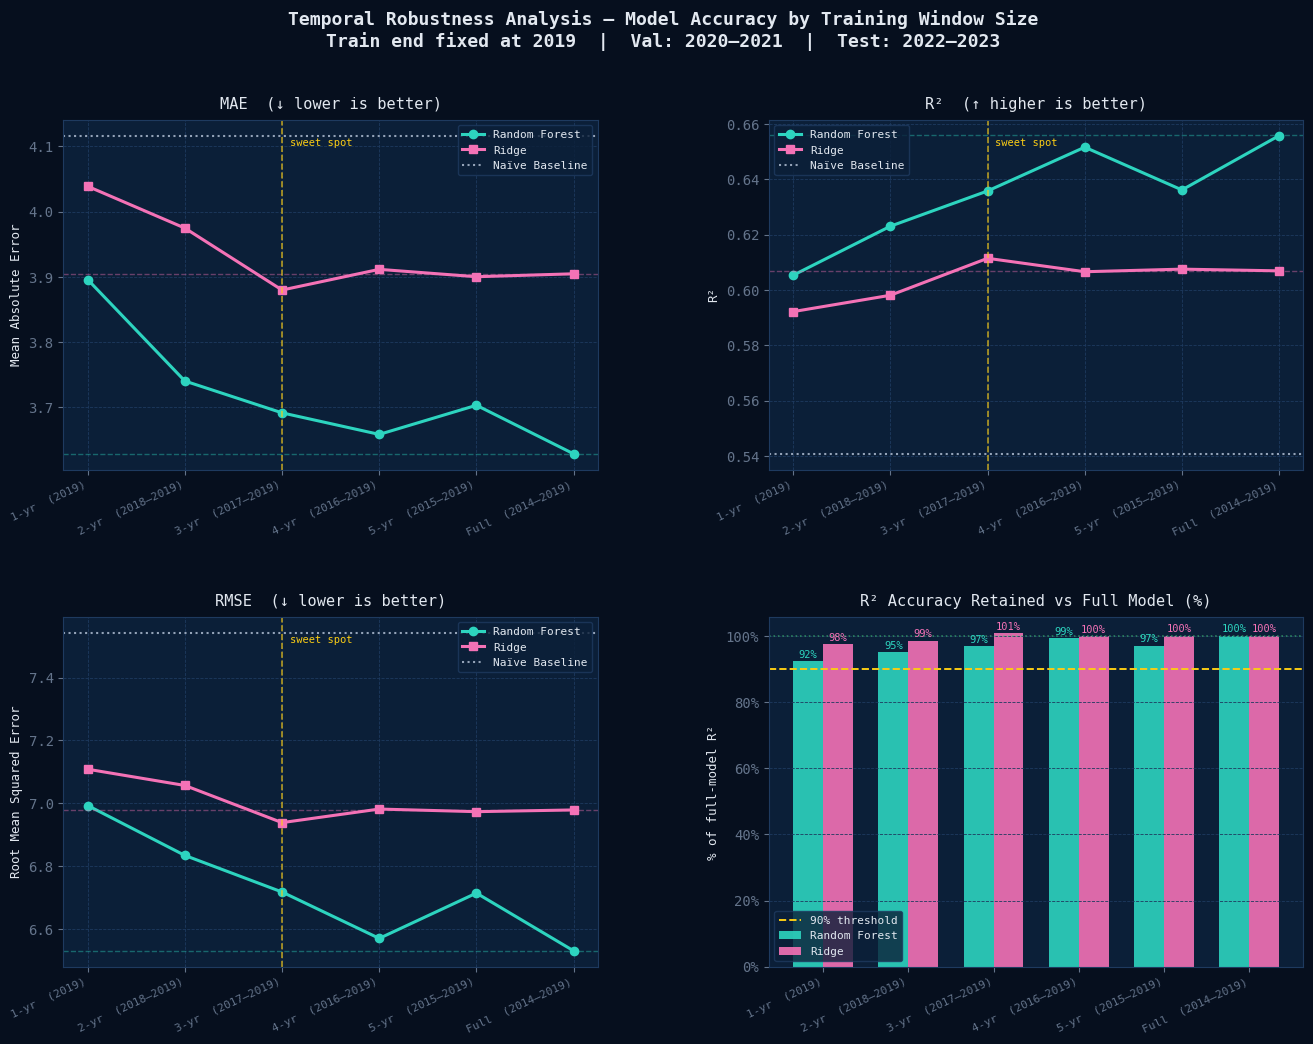

  Figure saved → ./feature_importance_shift.png


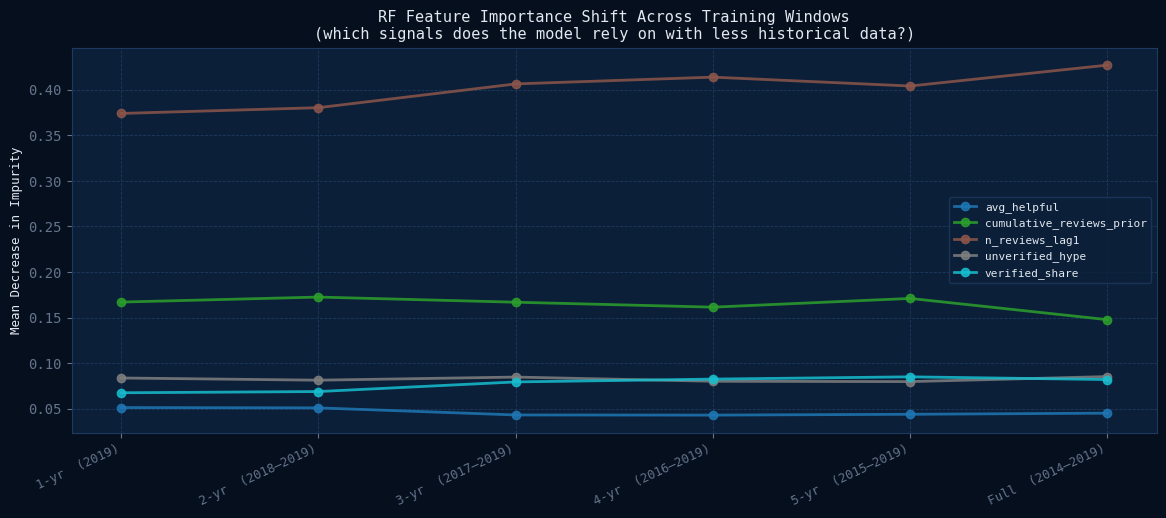


─────────────────────────────────────────────────────────────────
  KEY FINDINGS
─────────────────────────────────────────────────────────────────
  1-yr  (2019)              RF accuracy retained:  92.3%   ✓ beats baseline
  2-yr  (2018–2019)         RF accuracy retained:  95.0%   ✓ beats baseline
  3-yr  (2017–2019)         RF accuracy retained:  96.9%   ✓ beats baseline
  4-yr  (2016–2019)         RF accuracy retained:  99.4%   ✓ beats baseline
  5-yr  (2015–2019)         RF accuracy retained:  97.0%   ✓ beats baseline
  Full  (2014–2019)         RF accuracy retained: 100.0%   ✓ beats baseline
─────────────────────────────────────────────────────────────────



In [131]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
warnings.filterwarnings("ignore")
 
# ── Configuration ─────────────────────────────────────────────────────────────
OUTPUT_DIR = "."          # folder where figures + CSV will be saved
DATE_COL   = "year_month" # your date column name — change if different
DV_COL     = "n_reviews"  # dependent variable column name

final_modell_data = final_model_data.copy()
 
# ── Use your already-defined feature lists ────────────────────────────────────
# (defined earlier in your notebook — referenced here directly)
# features_regression = [...]
# features_trees      = [...]
 
# Ridge alpha candidates — same grid as your main analysis
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
 
# RF best hyperparameters from your main analysis — no re-tuning
RF_PARAMS = {
    "max_depth":        20,
    "max_features":     "sqrt",
    "min_samples_leaf": 1,
    "n_estimators":     200,
    "random_state":     42,
    "n_jobs":           -1,
}
 
# Training windows: (label, first year of train set)
# Val always = 2020-2021, Test always = 2022-2023
WINDOWS = [
    ("1-yr  (2019)",      2019),
    ("2-yr  (2018–2019)", 2018),
    ("3-yr  (2017–2019)", 2017),
    ("4-yr  (2016–2019)", 2016),
    ("5-yr  (2015–2019)", 2015),
    ("Full  (2014–2019)", 2014),
]
 
 
# ── Helper functions ──────────────────────────────────────────────────────────
 
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Return MAE, RMSE, R² for a prediction array."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}
 
 
def select_ridge_alpha_on_val(X_train_s, y_train, X_val_s, y_val) -> float:
    """
    Pick the Ridge alpha that gives lowest MAE on the validation set.
    Fits on train only — val is used purely for selection, never for fitting.
    """
    best_alpha, best_mae = None, np.inf
    for alpha in RIDGE_ALPHAS:
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train_s, y_train)
        mae = mean_absolute_error(y_val, ridge.predict(X_val_s))
        if mae < best_mae:
            best_mae, best_alpha = mae, alpha
    return best_alpha
 
 
def run_window(df: pd.DataFrame, label: str, train_start: int) -> dict:
    """
    Run naïve baseline + Ridge + Random Forest for one training window.
 
    Split:
        Train : train_start → 2019  (varies)
        Val   : 2020 → 2021         (fixed — alpha selection only)
        Test  : 2022 → 2023         (fixed — final evaluation)
    """
    print(f"\n{'='*65}")
    print(f"  Window : {label}  |  train = {train_start}–2019")
    print(f"{'='*65}")
 
    # ── Chronological split ───────────────────────────────────────────────
    train = df[df["year"].between(train_start, 2019)].copy()
    val   = df[df["year"].between(2020, 2021)].copy()
    test  = df[df["year"].between(2022, 2023)].copy()
 
    print(f"  Train : {len(train):>6,} obs  ({train_start}–2019)")
    print(f"  Val   : {len(val):>6,} obs  (2020–2021) ← fixed, alpha selection only")
    print(f"  Test  : {len(test):>6,} obs  (2022–2023) ← fixed, never touched during tuning")
 
    if len(train) < 50:
        print("  ⚠  Train set too small — skipping.")
        return None
 
    # ── Prepare arrays ────────────────────────────────────────────────────
    X_train_reg  = train[features_regression].values
    X_val_reg    = val[features_regression].values
    X_test_reg   = test[features_regression].values
 
    X_train_tree = train[features_trees].values
    X_test_tree  = test[features_trees].values
 
    y_train = train[DV_COL].values
    y_val   = val[DV_COL].values
    y_test  = test[DV_COL].values
 
    # ── Naïve persistence baseline ────────────────────────────────────────
    # Predict n_reviews_t = n_reviews_lag1_t  (same as your main analysis)
    lag1_idx = features_regression.index("n_reviews_lag1")
    y_naive  = X_test_reg[:, lag1_idx]
    m_naive  = compute_metrics(y_test, y_naive)
    print(f"\n  Naïve  → MAE={m_naive['MAE']:.4f}  "
          f"RMSE={m_naive['RMSE']:.4f}  R²={m_naive['R2']:.4f}")
 
    # ── Standardise: fit on TRAIN only, apply to val + test ───────────────
    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_reg)
    X_val_scaled   = scaler.transform(X_val_reg)
    X_test_scaled  = scaler.transform(X_test_reg)
 
    # ── Ridge: select alpha on val, re-fit on train, evaluate on test ─────
    best_alpha = select_ridge_alpha_on_val(
        X_train_scaled, y_train, X_val_scaled, y_val
    )
    ridge = Ridge(alpha=best_alpha)
    ridge.fit(X_train_scaled, y_train)
    y_ridge = ridge.predict(X_test_scaled)
    m_ridge = compute_metrics(y_test, y_ridge)
    print(f"  Ridge  → MAE={m_ridge['MAE']:.4f}  "
          f"RMSE={m_ridge['RMSE']:.4f}  R²={m_ridge['R2']:.4f}  "
          f"(best α={best_alpha} selected on val)")
 
    # ── Random Forest: fit on train, evaluate on test ─────────────────────
    rf = RandomForestRegressor(**RF_PARAMS)
    rf.fit(X_train_tree, y_train)
    y_rf = rf.predict(X_test_tree)
    m_rf = compute_metrics(y_test, y_rf)
    print(f"  RF     → MAE={m_rf['MAE']:.4f}  "
          f"RMSE={m_rf['RMSE']:.4f}  R²={m_rf['R2']:.4f}")
 
    # ── RF feature importances ────────────────────────────────────────────
    importances = pd.Series(
        rf.feature_importances_, index=features_trees
    ).sort_values(ascending=False)
 
    return {
        "label":            label,
        "train_start":      train_start,
        "n_train":          len(train),
        "n_val":            len(val),
        "n_test":           len(test),
        "ridge_alpha":      best_alpha,
        "MAE_naive":        m_naive["MAE"],
        "MAE_ridge":        m_ridge["MAE"],
        "MAE_rf":           m_rf["MAE"],
        "RMSE_naive":       m_naive["RMSE"],
        "RMSE_ridge":       m_ridge["RMSE"],
        "RMSE_rf":          m_rf["RMSE"],
        "R2_naive":         m_naive["R2"],
        "R2_ridge":         m_ridge["R2"],
        "R2_rf":            m_rf["R2"],
        "rf_importances":   importances.head(5).to_dict(),
    }
 
 
# ── Plotting ──────────────────────────────────────────────────────────────────
 
def plot_results(results_df: pd.DataFrame, main_results: dict = None) -> None:
    """
    2×2 figure:
      [0,0] MAE across windows
      [0,1] R²  across windows
      [1,0] RMSE across windows
      [1,1] % R² accuracy retained vs full model
    If main_results dict is provided, horizontal reference lines are drawn
    for your already-computed full-model results.
    """
    labels = results_df["label"].tolist()
    x      = np.arange(len(labels))
 
    full_r2_rf    = results_df["R2_rf"].iloc[-1]
    full_r2_ridge = results_df["R2_ridge"].iloc[-1]
    pct_rf        = results_df["R2_rf"]    / full_r2_rf    * 100
    pct_ridge     = results_df["R2_ridge"] / full_r2_ridge * 100
 
    BG      = "#060f1e"
    PANEL   = "#0b1f38"
    GRID    = "#1e3a5f"
    RF_C    = "#2dd4bf"
    RIDGE_C = "#f472b6"
    NAIVE_C = "#94a3b8"
    REF_C   = "#facc15"
    TEXT    = "#e2e8f0"
    MUTED   = "#64748b"
 
    plt.rcParams.update({
        "figure.facecolor": BG,   "axes.facecolor": PANEL,
        "axes.edgecolor":   GRID, "axes.labelcolor": TEXT,
        "xtick.color":      MUTED,"ytick.color":    MUTED,
        "text.color":       TEXT, "grid.color":     GRID,
        "grid.linestyle":   "--", "grid.linewidth": 0.6,
        "legend.facecolor": PANEL,"legend.edgecolor": GRID,
        "font.family":      "monospace",
    })
 
    fig = plt.figure(figsize=(16, 11), facecolor=BG)
    fig.suptitle(
        "Temporal Robustness Analysis — Model Accuracy by Training Window Size\n"
        "Train end fixed at 2019  |  Val: 2020–2021  |  Test: 2022–2023",
        fontsize=13, color=TEXT, y=0.98, fontweight="bold"
    )
    gs    = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
    sweet = 2  # index of the 3-year window — annotated as sweet spot
 
    def style_ax(ax, title, ylabel):
        ax.set_title(title, color=TEXT, fontsize=11, pad=8)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True)
        ax.axvline(sweet, color=REF_C, linestyle="--", lw=1.2, alpha=0.7)
        ylim = ax.get_ylim()
        ax.text(sweet + 0.08, ylim[1] - (ylim[1] - ylim[0]) * 0.05,
                "sweet spot", color=REF_C, fontsize=7.5, va="top")
 
    # Panel 1 — MAE
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(x, results_df["MAE_rf"],    color=RF_C,    marker="o", lw=2.2, label="Random Forest")
    ax1.plot(x, results_df["MAE_ridge"], color=RIDGE_C, marker="s", lw=2.2, label="Ridge")
    ax1.axhline(results_df["MAE_naive"].iloc[-1], color=NAIVE_C, linestyle=":", lw=1.5, label="Naïve Baseline")
    if main_results:
        ax1.axhline(main_results["MAE_rf"],    color=RF_C,    linestyle="--", lw=1, alpha=0.4)
        ax1.axhline(main_results["MAE_ridge"], color=RIDGE_C, linestyle="--", lw=1, alpha=0.4)
    style_ax(ax1, "MAE  (↓ lower is better)", "Mean Absolute Error")
 
    # Panel 2 — R²
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(x, results_df["R2_rf"],    color=RF_C,    marker="o", lw=2.2, label="Random Forest")
    ax2.plot(x, results_df["R2_ridge"], color=RIDGE_C, marker="s", lw=2.2, label="Ridge")
    ax2.axhline(results_df["R2_naive"].iloc[-1], color=NAIVE_C, linestyle=":", lw=1.5, label="Naïve Baseline")
    if main_results:
        ax2.axhline(main_results["R2_rf"],    color=RF_C,    linestyle="--", lw=1, alpha=0.4)
        ax2.axhline(main_results["R2_ridge"], color=RIDGE_C, linestyle="--", lw=1, alpha=0.4)
    style_ax(ax2, "R²  (↑ higher is better)", "R²")
 
    # Panel 3 — RMSE
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(x, results_df["RMSE_rf"],    color=RF_C,    marker="o", lw=2.2, label="Random Forest")
    ax3.plot(x, results_df["RMSE_ridge"], color=RIDGE_C, marker="s", lw=2.2, label="Ridge")
    ax3.axhline(results_df["RMSE_naive"].iloc[-1], color=NAIVE_C, linestyle=":", lw=1.5, label="Naïve Baseline")
    if main_results:
        ax3.axhline(main_results["RMSE_rf"],    color=RF_C,    linestyle="--", lw=1, alpha=0.4)
        ax3.axhline(main_results["RMSE_ridge"], color=RIDGE_C, linestyle="--", lw=1, alpha=0.4)
    style_ax(ax3, "RMSE  (↓ lower is better)", "Root Mean Squared Error")
 
    # Panel 4 — % R² retained
    ax4 = fig.add_subplot(gs[1, 1])
    bw = 0.35
    bars_rf    = ax4.bar(x - bw/2, pct_rf,    width=bw, color=RF_C,    label="Random Forest", alpha=0.9)
    bars_ridge = ax4.bar(x + bw/2, pct_ridge, width=bw, color=RIDGE_C, label="Ridge",         alpha=0.9)
    ax4.axhline(90,  color=REF_C,    linestyle="--", lw=1.4, label="90% threshold")
    ax4.axhline(100, color="#4ade80", linestyle=":",  lw=1.2, alpha=0.5)
    ax4.set_title("R² Accuracy Retained vs Full Model (%)", color=TEXT, fontsize=11, pad=8)
    ax4.set_xticks(x)
    ax4.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
    ax4.set_ylabel("% of full-model R²", fontsize=9)
    ax4.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax4.legend(fontsize=8)
    ax4.grid(True, axis="y")
    for bar, color in [(b, RF_C) for b in bars_rf] + [(b, RIDGE_C) for b in bars_ridge]:
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{bar.get_height():.0f}%", ha="center", va="bottom",
                 fontsize=7.5, color=color)
 
    out = f"{OUTPUT_DIR}/temporal_robustness_figure.png"
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG)
    print(f"\n  Figure saved → {out}")
    plt.show()
 
 
def plot_feature_importance_shift(all_results: list) -> None:
    """
    Line chart showing how RF feature importances shift across training windows.
    Helps answer: does the model rely on different signals with less data?
    """
    BG    = "#060f1e"; PANEL = "#0b1f38"; GRID = "#1e3a5f"
    TEXT  = "#e2e8f0"; MUTED = "#64748b"
 
    all_feats = set()
    for r in all_results:
        if r:
            all_feats.update(r["rf_importances"].keys())
 
    cmap   = plt.cm.get_cmap("tab10")
    colors = {f: cmap(i / max(len(all_feats) - 1, 1))
              for i, f in enumerate(sorted(all_feats))}
 
    fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=MUTED)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
 
    labels = [r["label"] for r in all_results if r]
    x      = np.arange(len(labels))
 
    for feat in sorted(all_feats):
        vals = [r["rf_importances"].get(feat, 0.0) for r in all_results if r]
        ax.plot(x, vals, marker="o", lw=2, label=feat,
                color=colors[feat], alpha=0.85)
 
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=9, color=MUTED)
    ax.set_ylabel("Mean Decrease in Impurity", fontsize=9, color=TEXT)
    ax.set_title(
        "RF Feature Importance Shift Across Training Windows\n"
        "(which signals does the model rely on with less historical data?)",
        color=TEXT, fontsize=11
    )
    ax.legend(fontsize=8, loc="center right")
    ax.grid(True, color=GRID, linestyle="--", linewidth=0.6)
 
    out = f"{OUTPUT_DIR}/feature_importance_shift.png"
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG)
    print(f"  Figure saved → {out}")
    plt.show()
 
 
# ── Summary table ─────────────────────────────────────────────────────────────
 
def print_results_table(results_df: pd.DataFrame) -> None:
    full_r2_rf = results_df["R2_rf"].iloc[-1]
 
    print("\n" + "=" * 115)
    print("TEMPORAL ROBUSTNESS — SUMMARY TABLE")
    print("Val fixed: 2020–2021  |  Test fixed: 2022–2023")
    print("=" * 115)
    print(f"{'Window':<24} {'N_train':>8} {'α':>7}  "
          f"{'MAE_naive':>10} {'MAE_ridge':>10} {'MAE_rf':>8}  "
          f"{'R2_naive':>9} {'R2_ridge':>9} {'R2_rf':>7}  "
          f"{'RF_acc%':>8}  {'Beats baseline?':>16}")
    print("-" * 115)
 
    for _, row in results_df.iterrows():
        pct   = row["R2_rf"] / full_r2_rf * 100
        beats = "YES ✓" if row["MAE_rf"] < row["MAE_naive"] else "NO  ✗"
        note  = " ← FULL" if row["label"].startswith("Full") else ""
        print(
            f"{row['label']:<24} {int(row['n_train']):>8,} {row['ridge_alpha']:>7.3f}  "
            f"{row['MAE_naive']:>10.4f} {row['MAE_ridge']:>10.4f} {row['MAE_rf']:>8.4f}  "
            f"{row['R2_naive']:>9.4f} {row['R2_ridge']:>9.4f} {row['R2_rf']:>7.4f}  "
            f"{pct:>7.1f}%  {beats}{note}"
        )
 
    print("=" * 115)
    out_csv = f"{OUTPUT_DIR}/temporal_robustness_results.csv"
    results_df.to_csv(out_csv, index=False)
    print(f"\n  Results table saved → {out_csv}")
 
 
# ── Main ──────────────────────────────────────────────────────────────────────
 
def run_temporal_robustness(main_results: dict = None):
    """
    Entry point. Call this from your notebook after running your main analysis.
 
    Parameters
    ----------
    main_results : dict, optional
        Pass your already-computed full-model test results so they appear
        as reference lines on the plots. Format:
            {
                "MAE_rf":    <float>,  "MAE_ridge":  <float>,
                "RMSE_rf":   <float>,  "RMSE_ridge": <float>,
                "R2_rf":     <float>,  "R2_ridge":   <float>,
            }
        If None, the last window (Full 2014–2019) is used as the reference.
    """
    print("\n" + "▓" * 65)
    print("  TEMPORAL ROBUSTNESS ANALYSIS")
    print("  Val: 2020–2021 (fixed)  |  Test: 2022–2023 (fixed)")
    print("▓" * 65)
 
    # ── Prepare the in-memory DataFrame ──────────────────────────────────
    df = final_modell_data.copy()
    df["year"] = pd.to_datetime(df[DATE_COL], format="%Y-%m", errors="coerce").dt.year
 
    print(f"\nLoaded {len(df):,} obs  |  "
          f"years {df['year'].min()}–{df['year'].max()}  |  "
          f"unique products: {df['n_reviews_lag1'].notna().sum():,}")
 
    # ── Run all windows ───────────────────────────────────────────────────
    all_results = []
    for label, train_start in WINDOWS:
        result = run_window(df, label, train_start)
        if result:
            all_results.append(result)
 
    if not all_results:
        print("No results produced — check column names.")
        return
 
    results_df = pd.DataFrame(all_results)
 
    # ── Output ────────────────────────────────────────────────────────────
    print_results_table(results_df)
    plot_results(results_df, main_results=main_results)
    plot_feature_importance_shift(all_results)
 
    # ── Narrative findings ────────────────────────────────────────────────
    full_r2_rf = results_df["R2_rf"].iloc[-1]
    print("\n" + "─" * 65)
    print("  KEY FINDINGS")
    print("─" * 65)
    for _, row in results_df.iterrows():
        pct   = row["R2_rf"] / full_r2_rf * 100
        beats = "✓ beats baseline" if row["MAE_rf"] < row["MAE_naive"] else "✗ does NOT beat baseline"
        print(f"  {row['label']:<24}  RF accuracy retained: {pct:5.1f}%   {beats}")
    print("─" * 65 + "\n")
 
    return results_df
 
 
# ── Call it ───────────────────────────────────────────────────────────────────
robustness_results = run_temporal_robustness(main_results={
    "MAE_rf":    3.629,   "MAE_ridge":  3.905,
    "RMSE_rf":   6.530,   "RMSE_ridge": 6.979,
    "R2_rf":     0.656,   "R2_ridge":   0.607,
})
 
 

In [139]:
#For heterogeneity analysis, exclude Unknown stores
final_model_data_heterogeneity = final_model_data[final_model_data['store'] != 'Unknown'].copy()
print(final_model_data_heterogeneity.isna().sum())

# Verify
print(f"Rows before: {len(final_model_data)}")
print(f"Rows after:  {len(final_model_data_heterogeneity)}")
print(f"Rows removed: {len(final_model_data) - len(final_model_data_heterogeneity)}")

parent_asin                  0
year_month                   0
n_reviews                    0
avg_review_length            0
avg_rating                   0
avg_helpful                  0
verified_share               0
next_month_date              0
days_diff                    0
n_reviews_lag1               0
cumulative_reviews           0
cumulative_reviews_prior     0
store                        0
avg_sentiment                0
sentiment_volatility         0
norm_rating                  0
norm_sentiment               0
sentiment_rating_gap         0
sentiment_change             0
verified_sentiment_signal    0
helpful_sentiment_impact     0
unverified_hype              0
dtype: int64
Rows before: 26606
Rows after:  25999
Rows removed: 607


In [141]:
# Check what type your column currently is
print(final_model_data_heterogeneity['year_month'].dtype)
print(final_model_data_heterogeneity['year_month'].head())

datetime64[ns]
0   2016-05-01
1   2016-06-01
2   2016-07-01
3   2016-08-01
4   2016-10-01
Name: year_month, dtype: datetime64[ns]


In [143]:
final_model_data_heterogeneity['year'] = pd.to_datetime(
    final_model_data_heterogeneity['year_month']
).dt.year

In [145]:
#Brand Strength Operationalization

#Compute brand_total_reviews on heterogeneity subset
brand_popularity = (
    final_model_data_heterogeneity
    .groupby('store')['n_reviews']
    .sum()
    .reset_index()
    .rename(columns={'n_reviews': 'brand_total_reviews'})
)
brand_popularity = brand_popularity.sort_values(
    by='brand_total_reviews', ascending=False)

#Merge back
if 'brand_total_reviews' in final_model_data_heterogeneity.columns:
    final_model_data_heterogeneity = final_model_data_heterogeneity.drop(
        columns=['brand_total_reviews'])
final_model_data_heterogeneity = final_model_data_heterogeneity.merge(
    brand_popularity, on='store', how='left')

In [147]:
#Check distribution
brand_stats = final_model_data_heterogeneity['brand_total_reviews'].describe(
    percentiles=[.25, .5, .75, .90])
print("── Brand Total Reviews Distribution ──")
print(brand_stats)

#Use dynamic median threshold
brand_threshold = final_model_data_heterogeneity['brand_total_reviews'].median()
print(f"\nMedian threshold: {brand_threshold}")

#Classify brands
final_model_data_heterogeneity['brand_strength'] = (
    final_model_data_heterogeneity['brand_total_reviews']
    .apply(lambda x: 'Strong' if x > brand_threshold else 'Weak')
)
final_model_data_heterogeneity['is_strong_brand'] = (
    final_model_data_heterogeneity['brand_total_reviews'] > brand_threshold
).astype(int)

#Verify
print(f"\n── Brand Strength Distribution ──")
print(final_model_data_heterogeneity['brand_strength'].value_counts())

── Brand Total Reviews Distribution ──
count    25999.000000
mean       645.858418
std       1870.450127
min         10.000000
25%         61.000000
50%        170.000000
75%        480.000000
90%       1056.000000
max      12752.000000
Name: brand_total_reviews, dtype: float64

Median threshold: 170.0

── Brand Strength Distribution ──
brand_strength
Weak      13066
Strong    12933
Name: count, dtype: int64


In [149]:
final_model_data_heterogeneity.head()

,parent_asin,year_month,n_reviews,avg_review_length,avg_rating,avg_helpful,verified_share,next_month_date,days_diff,n_reviews_lag1,...,norm_sentiment,sentiment_rating_gap,sentiment_change,verified_sentiment_signal,helpful_sentiment_impact,unverified_hype,year,brand_total_reviews,brand_strength,is_strong_brand
0,0629150591,2016-05-01,6,58,3.17,7.00,1.0,2016-06-01,31.0,7,...,0.798358,0.255858,0.000000,0.596717,4.773733,0.0,2016,32,Weak,0
1,0629150591,2016-06-01,7,13,3.71,1.43,1.0,2016-07-01,30.0,6,...,0.718443,0.040943,-0.159831,0.436886,1.061632,0.0,2016,32,Weak,0
2,0629150591,2016-07-01,7,20,4.86,0.00,1.0,2016-08-01,31.0,7,...,0.758621,0.206379,0.080357,0.517243,0.517243,0.0,2016,32,Weak,0
3,0629150591,2016-08-01,7,23,4.43,0.00,1.0,2016-09-01,31.0,7,...,0.615686,0.241814,-0.285871,0.231371,0.231371,0.0,2016,32,Weak,0
4,0629150591,2016-10-01,5,13,5.00,0.00,1.0,2016-11-01,31.0,7,...,0.860970,0.139030,0.490569,0.721940,0.721940,0.0,2016,32,Weak,0


In [151]:
brand_popularity.sort_values('brand_total_reviews', ascending=False).head(10)

,store,brand_total_reviews
1564,NELEUS,12752
427,Casio,7448
1906,Russell Athletic,6038
9,90 Degree By Reflex,3576
1632,Nurse Mates,2438
1989,Sabrina Silver,2419
492,Copper Fit,2404
1271,LILBETTER,2087
2070,Soundbot,2029
145,Aoxjox,1634


In [153]:
#Time-based splits on heterogeneity dataset
train_het = final_model_data_heterogeneity[
    final_model_data_heterogeneity['year_month'] <= '2019-12-01']
val_het   = final_model_data_heterogeneity[
    (final_model_data_heterogeneity['year_month'] >= '2020-01-01') & 
    (final_model_data_heterogeneity['year_month'] <= '2021-12-01')]
test_het  = final_model_data_heterogeneity[
    final_model_data_heterogeneity['year_month'] >= '2022-01-01']

print(f"Train: {len(train_het)}, Val: {len(val_het)}, Test: {len(test_het)}")

#Split by brand strength
train_strong = train_het[train_het['is_strong_brand'] == 1]
train_weak   = train_het[train_het['is_strong_brand'] == 0]
val_strong   = val_het[val_het['is_strong_brand'] == 1]
val_weak     = val_het[val_het['is_strong_brand'] == 0]
test_strong  = test_het[test_het['is_strong_brand'] == 1]
test_weak    = test_het[test_het['is_strong_brand'] == 0]

print(f"Train  — Strong: {len(train_strong)}, Weak: {len(train_weak)}")
print(f"Val    — Strong: {len(val_strong)}, Weak: {len(val_weak)}")
print(f"Test   — Strong: {len(test_strong)}, Weak: {len(test_weak)}")

#Define X and y for each group
X_train_strong, y_train_strong = train_strong[features_trees], train_strong['n_reviews']
X_train_weak,   y_train_weak   = train_weak[features_trees],   train_weak['n_reviews']
X_val_strong,   y_val_strong   = val_strong[features_trees],   val_strong['n_reviews']
X_val_weak,     y_val_weak     = val_weak[features_trees],     val_weak['n_reviews']
X_test_strong,  y_test_strong  = test_strong[features_trees],  test_strong['n_reviews']
X_test_weak,    y_test_weak    = test_weak[features_trees],    test_weak['n_reviews']

Train: 17645, Val: 5430, Test: 2924
Train  — Strong: 8672, Weak: 8973
Val    — Strong: 2738, Weak: 2692
Test   — Strong: 1523, Weak: 1401


In [155]:
#Verify no overlap
assert train_het['year_month'].max() < val_het['year_month'].min()
assert val_het['year_month'].max() < test_het['year_month'].min()
print("No overlap between splits")

#Verify group sizes are reasonable
print(f"\nTrain  — Strong: {len(train_strong)}, Weak: {len(train_weak)}")
print(f"Val    — Strong: {len(val_strong)}, Weak: {len(val_weak)}")
print(f"Test   — Strong: {len(test_strong)}, Weak: {len(test_weak)}")
print(f"\nTotal heterogeneity observations: {len(train_het) + len(val_het) + len(test_het)}")

No overlap between splits

Train  — Strong: 8672, Weak: 8973
Val    — Strong: 2738, Weak: 2692
Test   — Strong: 1523, Weak: 1401

Total heterogeneity observations: 25999


In [159]:
#Heterogeneity models with brand-specific tuning-XGBoost

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

#Strong brands
xgb_strong_cv = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
xgb_strong_cv.fit(X_train_strong, y_train_strong)
print(f"Strong brand best params: {xgb_strong_cv.best_params_}")

#Weak brands
xgb_weak_cv = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
xgb_weak_cv.fit(X_train_weak, y_train_weak)
print(f"Weak brand best params: {xgb_weak_cv.best_params_}")

#Evaluate on validation set
print("\n── Strong Brands — Validation ──")
evaluate_model('XGBoost Strong (val)', y_val_strong, 
               xgb_strong_cv.predict(X_val_strong))

print("\n── Weak Brands — Validation ──")
evaluate_model('XGBoost Weak (val)', y_val_weak, 
               xgb_weak_cv.predict(X_val_weak))

#Evaluate on test set
print("\n── Strong Brands — Test ──")
evaluate_model('XGBoost Strong (test)', y_test_strong, 
               xgb_strong_cv.predict(X_test_strong))

print("\n── Weak Brands — Test ──")
evaluate_model('XGBoost Weak (test)', y_test_weak, 
               xgb_weak_cv.predict(X_test_weak))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Strong brand best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Weak brand best params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}

── Strong Brands — Validation ──

XGBoost Strong (val)
  MAE:  6.0349
  RMSE: 12.4339
  R²:   0.5702

── Weak Brands — Validation ──

XGBoost Weak (val)
  MAE:  1.5755
  RMSE: 3.3430
  R²:   0.4963

── Strong Brands — Test ──

XGBoost Strong (test)
  MAE:  6.1422
  RMSE: 12.6962
  R²:   0.1979

── Weak Brands — Test ──

XGBoost Weak (test)
  MAE:  1.6158
  RMSE: 3.2905
  R²:   0.4653


{'Model': 'XGBoost Weak (test)', 'MAE': 1.6158, 'RMSE': 3.2905, 'R2': 0.4653}

In [160]:
#Feature importance comparison-XGBoost
importance_comparison = pd.DataFrame({
    'Feature': features_trees,
    'Importance_Strong': xgb_strong_cv.best_estimator_.feature_importances_,
    'Importance_Weak': xgb_weak_cv.best_estimator_.feature_importances_
}).sort_values(by='Importance_Strong', ascending=False)

print("\n── Feature Importance: Strong vs Weak Brands ──")
print(importance_comparison.to_string(index=False))

#Cumulative importance
importance_comparison['Cumulative_Strong'] = importance_comparison['Importance_Strong'].cumsum()
importance_comparison['Cumulative_Weak'] = importance_comparison['Importance_Weak'].cumsum()

print("\n── Cumulative Feature Importance ──")
print(importance_comparison[['Feature',
                               'Importance_Strong',
                               'Cumulative_Strong',
                               'Importance_Weak',
                               'Cumulative_Weak']].to_string(index=False))


── Feature Importance: Strong vs Weak Brands ──
                  Feature  Importance_Strong  Importance_Weak
           n_reviews_lag1           0.365250         0.147117
           verified_share           0.173649         0.315770
 cumulative_reviews_prior           0.156721         0.044525
          unverified_hype           0.064779         0.062477
              avg_helpful           0.048404         0.094488
verified_sentiment_signal           0.043246         0.031448
               avg_rating           0.029334         0.081966
 helpful_sentiment_impact           0.028330         0.029259
            avg_sentiment           0.021704         0.029767
     sentiment_volatility           0.021317         0.053225
         sentiment_change           0.021257         0.040246
     sentiment_rating_gap           0.016753         0.032950
        avg_review_length           0.009255         0.036763

── Cumulative Feature Importance ──
                  Feature  Importance_Strong  

In [161]:
#Heterogeneity analysis-Random Forest

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

#Strong Brands
rf_strong = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
rf_strong.fit(X_train_strong, y_train_strong)
print(f"Strong brand best params: {rf_strong.best_params_}")

#Weak Brands
rf_weak = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
rf_weak.fit(X_train_weak, y_train_weak)
print(f"Weak brand best params: {rf_weak.best_params_}")

#Evaluate on validation set
print("\n── Strong Brands — Validation ──")
evaluate_model('RF Strong (val)', y_val_strong,
               rf_strong.predict(X_val_strong))

print("\n── Weak Brands — Validation ──")
evaluate_model('RF Weak (val)', y_val_weak,
               rf_weak.predict(X_val_weak))

#Evaluate on test set
print("\n── Strong Brands — Test ──")
evaluate_model('RF Strong (test)', y_test_strong,
               rf_strong.predict(X_test_strong))

print("\n── Weak Brands — Test ──")
evaluate_model('RF Weak (test)', y_test_weak,
               rf_weak.predict(X_test_weak))

#Feature importance comparison-Random Forest
importance_rf = pd.DataFrame({
    'Feature': features_trees,
    'Importance_Strong': rf_strong.best_estimator_.feature_importances_,
    'Importance_Weak': rf_weak.best_estimator_.feature_importances_
}).sort_values(by='Importance_Strong', ascending=False)

print("\n── Feature Importance: Strong vs Weak Brands ──")
print(importance_rf.to_string(index=False))

#Cumulative importance
importance_rf['Cumulative_Strong'] = importance_rf['Importance_Strong'].cumsum()
importance_rf['Cumulative_Weak'] = importance_rf['Importance_Weak'].cumsum()

print("\n── Cumulative Feature Importance ──")
print(importance_rf[['Feature',
                       'Importance_Strong',
                       'Cumulative_Strong',
                       'Importance_Weak',
                       'Cumulative_Weak']].to_string(index=False))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Strong brand best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Weak brand best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}

── Strong Brands — Validation ──

RF Strong (val)
  MAE:  5.2874
  RMSE: 9.8913
  R²:   0.7280

── Weak Brands — Validation ──

RF Weak (val)
  MAE:  1.8953
  RMSE: 3.6403
  R²:   0.4028

── Strong Brands — Test ──

RF Strong (test)
  MAE:  4.9777
  RMSE: 8.1834
  R²:   0.6668

── Weak Brands — Test ──

RF Weak (test)
  MAE:  1.9977
  RMSE: 3.6288
  R²:   0.3497

── Feature Importance: Strong vs Weak Brands ──
                  Feature  Importance_Strong  Importance_Weak
           n_reviews_lag1           0.430312         0.174907
 cumulative_reviews_prior           0.129579         0.055678
          unverified_hype           0.084852       

In [162]:
#Heterogeneity analysis results table

het_results_table = pd.DataFrame({
    'Model': [
        'Random Forest', 'Random Forest',
        'XGBoost', 'XGBoost'
    ],
    'Brand Group': [
        'Strong', 'Weak',
        'Strong', 'Weak'
    ],
    'MAE': [
        4.9777, 1.9977,
        6.1422, 1.6158
    ],
    'RMSE': [
        8.1834, 3.6288,
        12.6962, 3.2905
    ],
    'R²': [
        0.6668, 0.3497,
        0.1979, 0.4653
    ]
})

print("── Heterogeneity Analysis — Model Performance (Test Set) ──")
print(het_results_table.to_string(index=False))

#Feature importance comparison table

#Combine RF and XGBoost feature importance
feature_importance_table = pd.DataFrame({
    'Feature': features_trees,
    'RF Strong': rf_strong.best_estimator_.feature_importances_,
    'RF Weak': rf_weak.best_estimator_.feature_importances_,
    'XGB Strong': xgb_strong_cv.best_estimator_.feature_importances_,
    'XGB Weak': xgb_weak_cv.best_estimator_.feature_importances_
}).sort_values(by='RF Strong', ascending=False)

#Round to 4 decimal places
feature_importance_table = feature_importance_table.round(4)

print("\n── Feature Importance: Strong vs Weak Brands ──")
print(feature_importance_table.to_string(index=False))

#Difference table
#Shows which features are more important for strong vs weak brands
feature_importance_table['RF Diff (Strong-Weak)'] = (
    feature_importance_table['RF Strong'] - 
    feature_importance_table['RF Weak']
).round(4)

feature_importance_table['XGB Diff (Strong-Weak)'] = (
    feature_importance_table['XGB Strong'] - 
    feature_importance_table['XGB Weak']
).round(4)

print("\n── Feature Importance Difference (Strong minus Weak) ──")
print("Positive = more important for Strong brands")
print("Negative = more important for Weak brands")
print()
print(feature_importance_table[['Feature', 
                                  'RF Diff (Strong-Weak)',
                                  'XGB Diff (Strong-Weak)']].to_string(index=False))

── Heterogeneity Analysis — Model Performance (Test Set) ──
        Model Brand Group    MAE    RMSE     R²
Random Forest      Strong 4.9777  8.1834 0.6668
Random Forest        Weak 1.9977  3.6288 0.3497
      XGBoost      Strong 6.1422 12.6962 0.1979
      XGBoost        Weak 1.6158  3.2905 0.4653

── Feature Importance: Strong vs Weak Brands ──
                  Feature  RF Strong  RF Weak  XGB Strong  XGB Weak
           n_reviews_lag1     0.4303   0.1749      0.3653    0.1471
 cumulative_reviews_prior     0.1296   0.0557      0.1567    0.0445
          unverified_hype     0.0849   0.0780      0.0648    0.0625
           verified_share     0.0847   0.0931      0.1736    0.3158
              avg_helpful     0.0433   0.0926      0.0484    0.0945
     sentiment_volatility     0.0360   0.0751      0.0213    0.0532
               avg_rating     0.0321   0.0708      0.0293    0.0820
            avg_sentiment     0.0285   0.0606      0.0217    0.0298
     sentiment_rating_gap     0.0277   

In [163]:
#XGBoost Early Stopping: Strong Brands
xgb_strong_early = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=0.7,
    random_state=42,
    early_stopping_rounds=10
)

xgb_strong_early.fit(
    X_train_strong, y_train_strong,
    eval_set=[(X_val_strong, y_val_strong)],
    verbose=100
)

#Performance for Strong Brands
strong_early_val_pred = xgb_strong_early.predict(X_val_strong)
strong_early_test_pred = xgb_strong_early.predict(X_test_strong)

print("── XGBoost Early Stopping — Strong Brands Validation ──")
print(f"  MAE:  {mean_absolute_error(y_val_strong, strong_early_val_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_val_strong, strong_early_val_pred)):.4f}")
print(f"  R²:   {r2_score(y_val_strong, strong_early_val_pred):.4f}")

print("\n── XGBoost Early Stopping — Strong Brands Test ──")
print(f"  MAE:  {mean_absolute_error(y_test_strong, strong_early_test_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_strong, strong_early_test_pred)):.4f}")
print(f"  R²:   {r2_score(y_test_strong, strong_early_test_pred):.4f}")

#Feature Importance: Strong Brands
xgb_strong_early_importance = pd.DataFrame({
    'Feature': features_trees,
    'Importance': xgb_strong_early.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n── XGBoost Early Stopping Feature Importance — Strong Brands ──")
print(xgb_strong_early_importance.to_string(index=False))

xgb_strong_early_importance['Cumulative_Importance'] = xgb_strong_early_importance['Importance'].cumsum()
print("\n── Cumulative Feature Importance — Strong Brands ──")
print(xgb_strong_early_importance[['Feature', 'Importance', 'Cumulative_Importance']].to_string(index=False))


#XGBoost Early Stopping: Weak Brands
xgb_weak_early = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=0.7,
    random_state=42,
    early_stopping_rounds=10
)

xgb_weak_early.fit(
    X_train_weak, y_train_weak,
    eval_set=[(X_val_weak, y_val_weak)],
    verbose=100
)

#Performance: Weak Brands
weak_early_val_pred = xgb_weak_early.predict(X_val_weak)
weak_early_test_pred = xgb_weak_early.predict(X_test_weak)

print("\n── XGBoost Early Stopping — Weak Brands Validation ──")
print(f"  MAE:  {mean_absolute_error(y_val_weak, weak_early_val_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_val_weak, weak_early_val_pred)):.4f}")
print(f"  R²:   {r2_score(y_val_weak, weak_early_val_pred):.4f}")

print("\n── XGBoost Early Stopping — Weak Brands Test ──")
print(f"  MAE:  {mean_absolute_error(y_test_weak, weak_early_test_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_weak, weak_early_test_pred)):.4f}")
print(f"  R²:   {r2_score(y_test_weak, weak_early_test_pred):.4f}")

#Feature Importance: Weak Brands
xgb_weak_early_importance = pd.DataFrame({
    'Feature': features_trees,
    'Importance': xgb_weak_early.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n── XGBoost Early Stopping Feature Importance — Weak Brands ──")
print(xgb_weak_early_importance.to_string(index=False))

xgb_weak_early_importance['Cumulative_Importance'] = xgb_weak_early_importance['Importance'].cumsum()
print("\n── Cumulative Feature Importance — Weak Brands ──")
print(xgb_weak_early_importance[['Feature', 'Importance', 'Cumulative_Importance']].to_string(index=False))


#Combined Feature Importance Comparison
combined_importance = pd.DataFrame({
    'Feature': features_trees,
    'Importance_Strong': xgb_strong_early.feature_importances_,
    'Importance_Weak': xgb_weak_early.feature_importances_
}).sort_values('Importance_Strong', ascending=False)

print("\n── XGBoost Early Stopping: Strong vs Weak Feature Importance ──")
print(combined_importance.to_string(index=False))

[0]	validation_0-rmse:18.64146
[67]	validation_0-rmse:10.36609
── XGBoost Early Stopping — Strong Brands Validation ──
  MAE:  5.8055
  RMSE: 10.2780
  R²:   0.7063

── XGBoost Early Stopping — Strong Brands Test ──
  MAE:  5.5921
  RMSE: 8.6310
  R²:   0.6293

── XGBoost Early Stopping Feature Importance — Strong Brands ──
                  Feature  Importance
           n_reviews_lag1    0.350353
 cumulative_reviews_prior    0.248702
           verified_share    0.143928
          unverified_hype    0.052530
              avg_helpful    0.042924
               avg_rating    0.037240
verified_sentiment_signal    0.028218
         sentiment_change    0.021363
 helpful_sentiment_impact    0.019226
            avg_sentiment    0.016835
     sentiment_volatility    0.016456
     sentiment_rating_gap    0.012271
        avg_review_length    0.009955

── Cumulative Feature Importance — Strong Brands ──
                  Feature  Importance  Cumulative_Importance
           n_reviews_lag1   

In [133]:
#Descriptive statistics

#Key variables descriptive statistics
key_vars = ['n_reviews', 'n_reviews_lag1', 'avg_rating', 'avg_sentiment',
            'avg_helpful', 'verified_share', 'avg_review_length',
            'cumulative_reviews_prior', 'sentiment_rating_gap',
            'sentiment_change', 'sentiment_volatility',
            'verified_sentiment_signal', 'helpful_sentiment_impact',
            'unverified_hype']

desc_stats = final_model_data2[key_vars].describe(
    percentiles=[.25, .5, .75, .90]
).round(4)

print("── Descriptive Statistics ──")
print(desc_stats.to_string())

#Distribution of DV
print("\n── DV Distribution (n_reviews) ──")
print(f"Mean:   {final_model_data2['n_reviews'].mean():.4f}")
print(f"Median: {final_model_data2['n_reviews'].median():.4f}")
print(f"Std:    {final_model_data2['n_reviews'].std():.4f}")
print(f"Skew:   {final_model_data2['n_reviews'].skew():.4f}")
print(f"Min:    {final_model_data2['n_reviews'].min():.4f}")
print(f"Max:    {final_model_data2['n_reviews'].max():.4f}")

#Positivity bias check
print("\n── Positivity Bias ──")
print(f"% 5-star reviews: {(final_model_data2['avg_rating'] >= 4.5).sum() / len(final_model_data2) * 100:.2f}%")
print(f"Mean avg_rating:  {final_model_data2['avg_rating'].mean():.4f}")
print(f"Mean avg_sentiment: {final_model_data2['avg_sentiment'].mean():.4f}")

#Sentiment distribution
print("\n── Sentiment Distribution ──")
positive = (final_model_data2['avg_sentiment'] > 0.05).sum()
neutral  = ((final_model_data2['avg_sentiment'] >= -0.05) & 
            (final_model_data2['avg_sentiment'] <= 0.05)).sum()
negative = (final_model_data2['avg_sentiment'] < -0.05).sum()
total    = len(final_model_data2)

print(f"Positive (>0.05):  {positive} ({positive/total*100:.2f}%)")
print(f"Neutral  (±0.05):  {neutral}  ({neutral/total*100:.2f}%)")
print(f"Negative (<-0.05): {negative} ({negative/total*100:.2f}%)")

#Verified purchase share distribution
print("\n── Verified Purchase Share ──")
print(f"Mean:   {final_model_data2['verified_share'].mean():.4f}")
print(f"Median: {final_model_data2['verified_share'].median():.4f}")
print(f"% fully verified (=1.0): {(final_model_data2['verified_share'] == 1.0).sum() / total * 100:.2f}%")

#Review volume by year
print("\n── Review Volume by Year ──")
final_model_data2['year'] = pd.to_datetime(
    final_model_data2['year_month']).dt.year
print(final_model_data2.groupby('year')['n_reviews'].agg(
    ['count', 'mean', 'median']).round(2))

#Correlation matrix
print("\n── Correlation Matrix (core IVs) ──")
core_vars = ['n_reviews_lag1', 'avg_rating', 
             'avg_sentiment', 'avg_helpful', 'verified_share']
print(final_model_data2[core_vars].corr().round(4))

── Descriptive Statistics ──
        n_reviews  n_reviews_lag1  avg_rating  avg_sentiment  avg_helpful  verified_share  avg_review_length  cumulative_reviews_prior  sentiment_rating_gap  sentiment_change  sentiment_volatility  verified_sentiment_signal  helpful_sentiment_impact  unverified_hype
count  26606.0000      26606.0000  26606.0000     26606.0000   26606.0000      26606.0000         26606.0000                26606.0000            26606.0000        26606.0000            26606.0000                 26606.0000                26606.0000       26606.0000
mean      10.5514         10.6534      4.0558         0.5616       0.6816          0.9428            30.7088                  164.1063                0.0911           -0.0113                0.4097                     0.5262                    0.9595           0.2369
std       11.4019         11.4106      0.7264         0.2304       1.9787          0.1460            17.3662                  480.0109                0.0775            0.

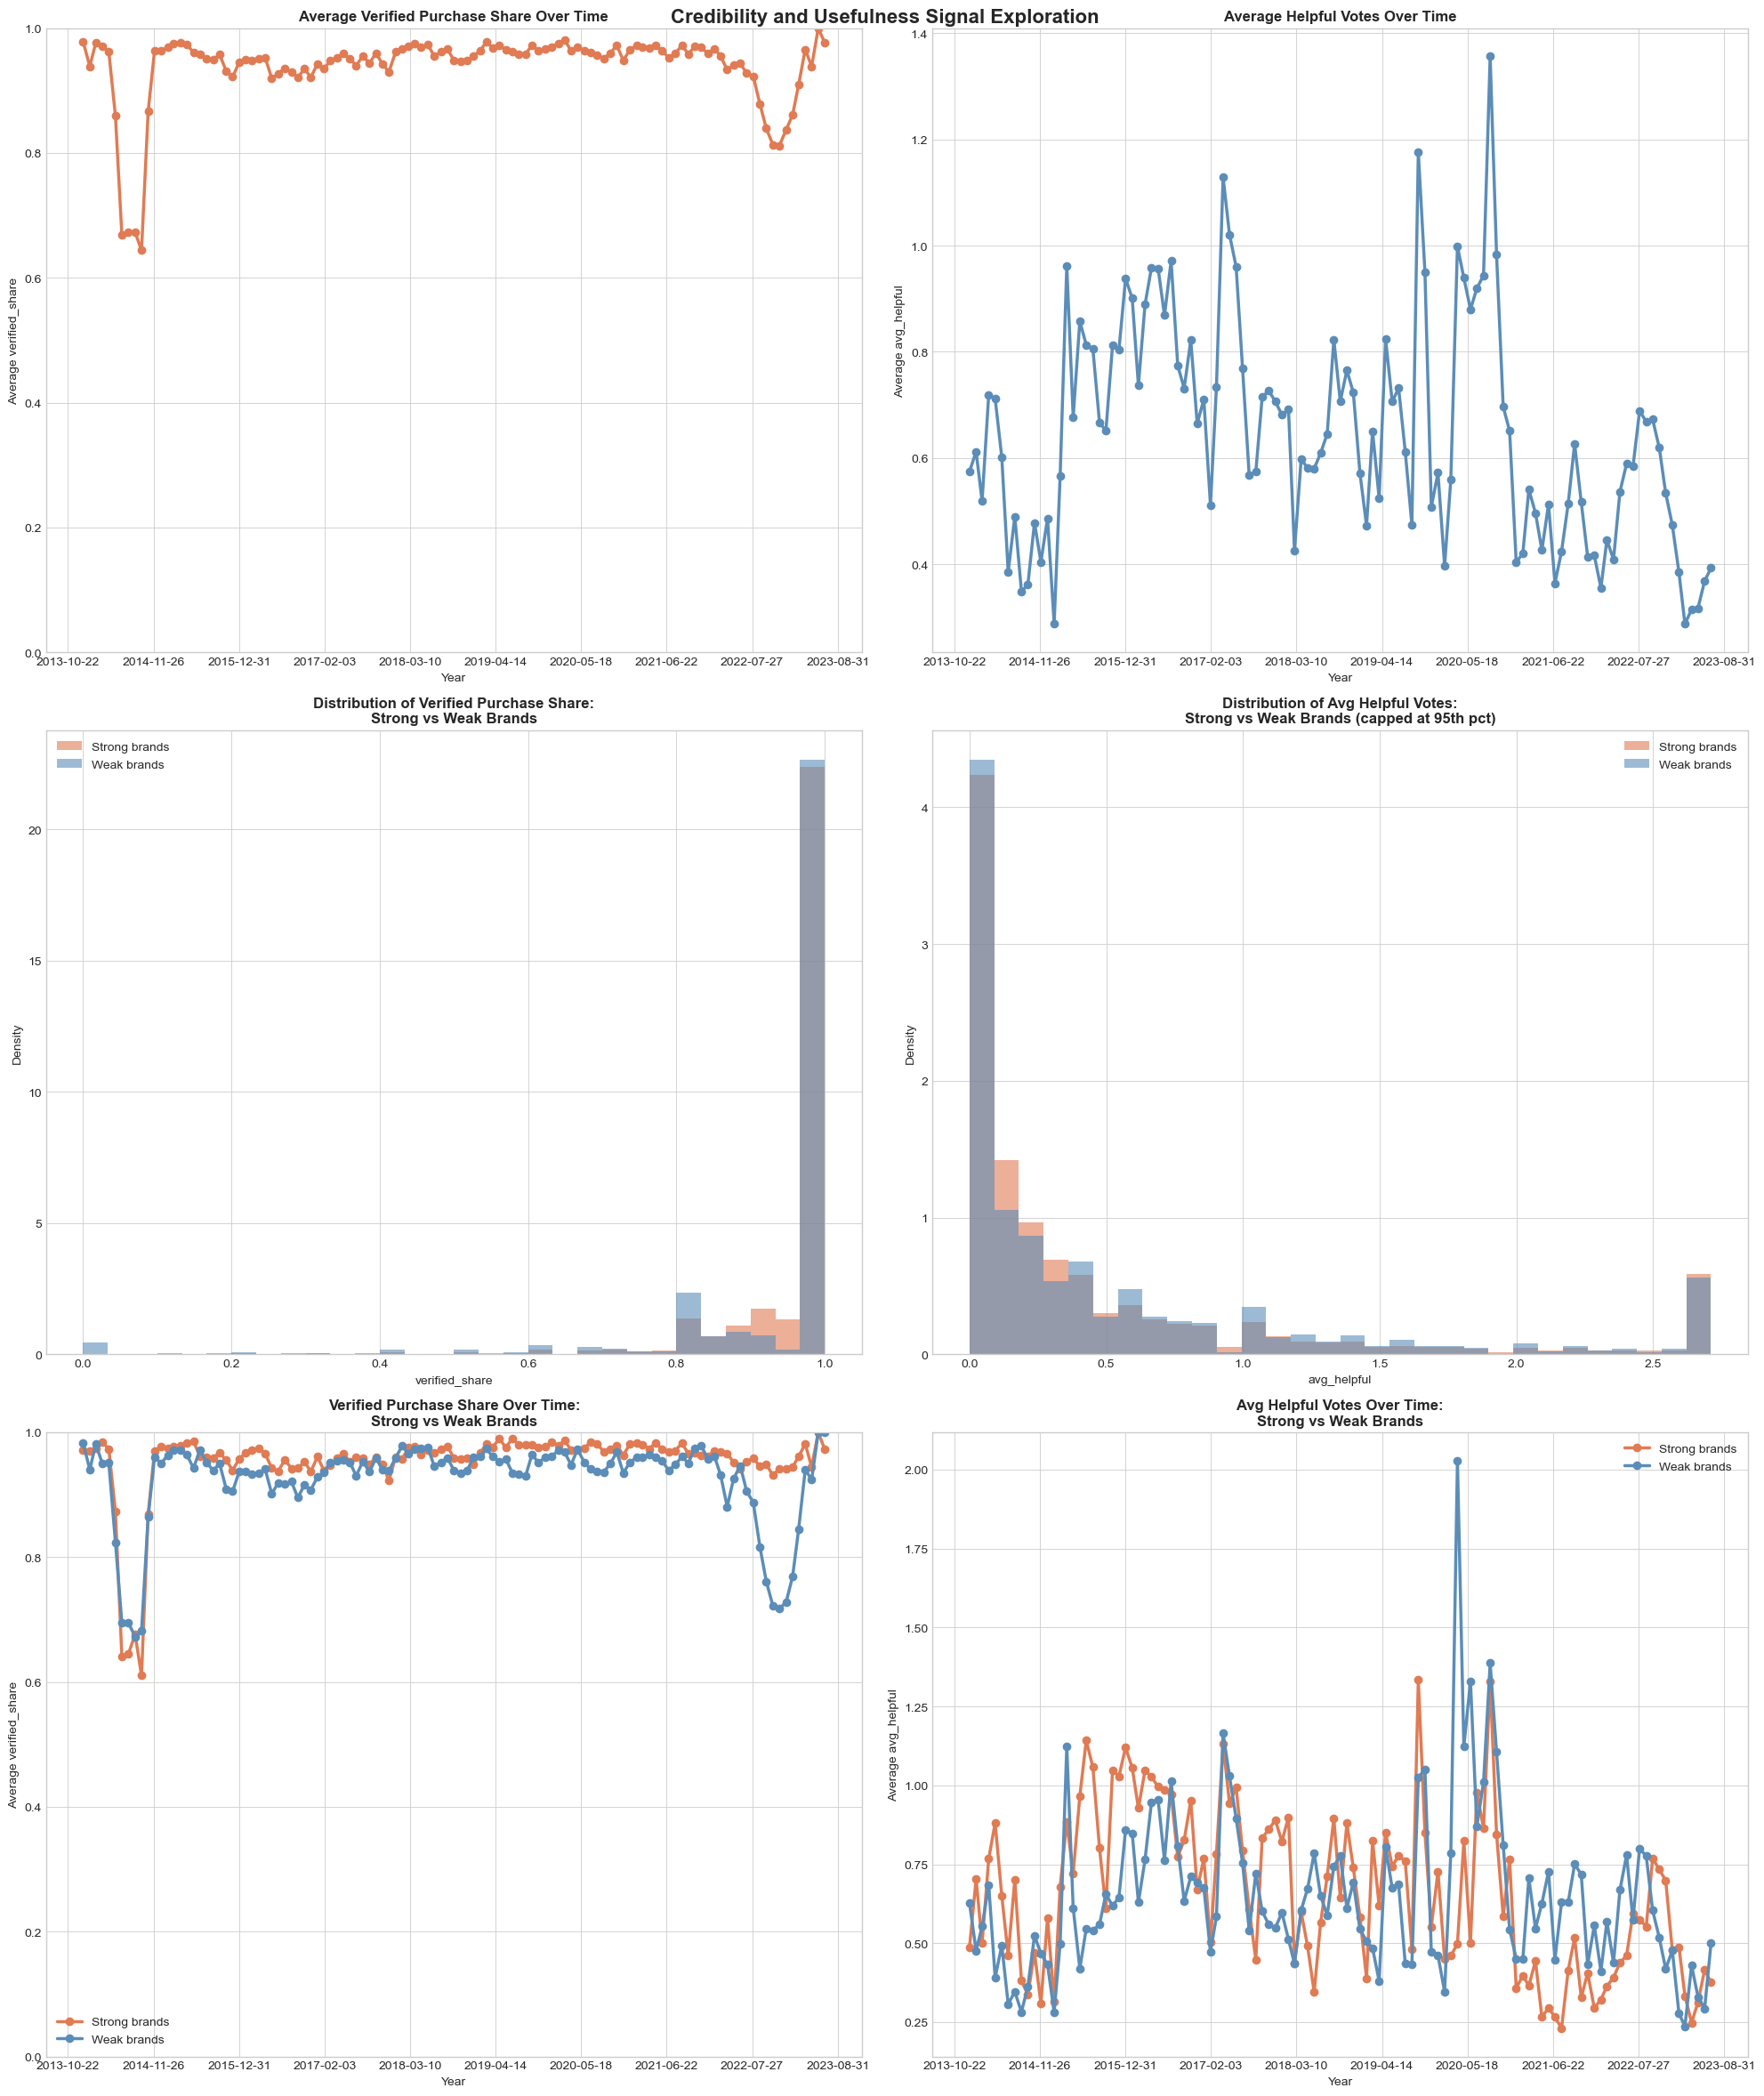

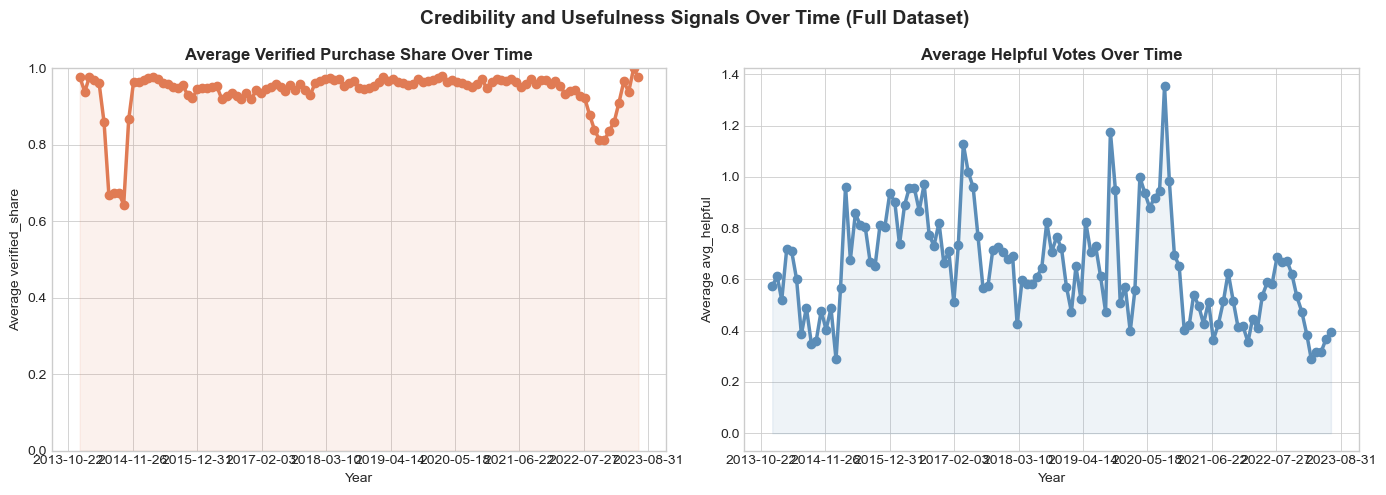

── Verified Share: Strong vs Weak ──
                   count   mean    std  min   25%  50%  75%  max
is_strong_brand                                                 
0                13066.0  0.929  0.177  0.0  1.00  1.0  1.0  1.0
1                12933.0  0.957  0.103  0.0  0.96  1.0  1.0  1.0

── Avg Helpful: Strong vs Weak ──
                   count   mean    std  min  25%   50%   75%    max
is_strong_brand                                                    
0                13066.0  0.669  1.742  0.0  0.0  0.20  0.67  46.83
1                12933.0  0.696  2.194  0.0  0.0  0.17  0.57  56.60


In [157]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 24))
fig.suptitle('Credibility and Usefulness Signal Exploration', fontsize=16, fontweight='bold', y=0.98)

#Verified_share over time
ax1 = fig.add_subplot(3, 2, 1)
yearly_verified = final_model_data.groupby('year_month')['verified_share'].mean().reset_index()
ax1.plot(yearly_verified['year_month'], yearly_verified['verified_share'], 
         marker='o', color='#E07B54', linewidth=2.5, markersize=6)
ax1.set_title('Average Verified Purchase Share Over Time', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average verified_share')
ax1.set_ylim(0, 1)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

#avg_helpful over time
ax2 = fig.add_subplot(3, 2, 2)
yearly_helpful = final_model_data.groupby('year_month')['avg_helpful'].mean().reset_index()
ax2.plot(yearly_helpful['year_month'], yearly_helpful['avg_helpful'], 
         marker='o', color='#5B8DB8', linewidth=2.5, markersize=6)
ax2.set_title('Average Helpful Votes Over Time', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average avg_helpful')
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

#verified_share distribution: strong vs weak brands
ax3 = fig.add_subplot(3, 2, 3)
strong_verified = final_model_data_heterogeneity[
    final_model_data_heterogeneity['is_strong_brand'] == 1]['verified_share']
weak_verified = final_model_data_heterogeneity[
    final_model_data_heterogeneity['is_strong_brand'] == 0]['verified_share']
ax3.hist(strong_verified, bins=30, alpha=0.6, color='#E07B54', 
         label='Strong brands', density=True)
ax3.hist(weak_verified, bins=30, alpha=0.6, color='#5B8DB8', 
         label='Weak brands', density=True)
ax3.set_title('Distribution of Verified Purchase Share:\nStrong vs Weak Brands', 
              fontweight='bold')
ax3.set_xlabel('verified_share')
ax3.set_ylabel('Density')
ax3.legend()

#avg_helpful distribution: strong vs weak brands
ax4 = fig.add_subplot(3, 2, 4)
strong_helpful = final_model_data_heterogeneity[
    final_model_data_heterogeneity['is_strong_brand'] == 1]['avg_helpful']
weak_helpful = final_model_data_heterogeneity[
    final_model_data_heterogeneity['is_strong_brand'] == 0]['avg_helpful']
#Cap at 95th percentile for readability
cap = final_model_data_heterogeneity['avg_helpful'].quantile(0.95)
ax4.hist(strong_helpful.clip(upper=cap), bins=30, alpha=0.6, 
         color='#E07B54', label='Strong brands', density=True)
ax4.hist(weak_helpful.clip(upper=cap), bins=30, alpha=0.6, 
         color='#5B8DB8', label='Weak brands', density=True)
ax4.set_title('Distribution of Avg Helpful Votes:\nStrong vs Weak Brands (capped at 95th pct)', 
              fontweight='bold')
ax4.set_xlabel('avg_helpful')
ax4.set_ylabel('Density')
ax4.legend()

#verified_share by year: strong vs weak
ax5 = fig.add_subplot(3, 2, 5)
yearly_verified_brand = final_model_data_heterogeneity.groupby(
    ['year_month', 'is_strong_brand'])['verified_share'].mean().reset_index()
strong_yearly = yearly_verified_brand[yearly_verified_brand['is_strong_brand'] == 1]
weak_yearly = yearly_verified_brand[yearly_verified_brand['is_strong_brand'] == 0]
ax5.plot(strong_yearly['year_month'], strong_yearly['verified_share'], 
         marker='o', color='#E07B54', linewidth=2.5, markersize=6, label='Strong brands')
ax5.plot(weak_yearly['year_month'], weak_yearly['verified_share'], 
         marker='o', color='#5B8DB8', linewidth=2.5, markersize=6, label='Weak brands')
ax5.set_title('Verified Purchase Share Over Time:\nStrong vs Weak Brands', fontweight='bold')
ax5.set_xlabel('Year')
ax5.set_ylabel('Average verified_share')
ax5.set_ylim(0, 1)
ax5.legend()
ax5.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

#avg_helpful by year: strong vs weak
ax6 = fig.add_subplot(3, 2, 6)
yearly_helpful_brand = final_model_data_heterogeneity.groupby(
    ['year_month', 'is_strong_brand'])['avg_helpful'].mean().reset_index()
strong_helpful_yearly = yearly_helpful_brand[yearly_helpful_brand['is_strong_brand'] == 1]
weak_helpful_yearly = yearly_helpful_brand[yearly_helpful_brand['is_strong_brand'] == 0]
ax6.plot(strong_helpful_yearly['year_month'], strong_helpful_yearly['avg_helpful'], 
         marker='o', color='#E07B54', linewidth=2.5, markersize=6, label='Strong brands')
ax6.plot(weak_helpful_yearly['year_month'], weak_helpful_yearly['avg_helpful'], 
         marker='o', color='#5B8DB8', linewidth=2.5, markersize=6, label='Weak brands')
ax6.set_title('Avg Helpful Votes Over Time:\nStrong vs Weak Brands', fontweight='bold')
ax6.set_xlabel('Year')
ax6.set_ylabel('Average avg_helpful')
ax6.legend()
ax6.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('credibility_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

#verified_share by year
fig2, (ax7, ax8) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Credibility and Usefulness Signals Over Time (Full Dataset)', 
              fontsize=14, fontweight='bold')

yearly_verified_full = final_model_data.groupby('year_month')['verified_share'].mean().reset_index()
ax7.plot(yearly_verified_full['year_month'], yearly_verified_full['verified_share'], 
         marker='o', color='#E07B54', linewidth=2.5, markersize=6)
ax7.fill_between(yearly_verified_full['year_month'], yearly_verified_full['verified_share'], 
                  alpha=0.1, color='#E07B54')
ax7.set_title('Average Verified Purchase Share Over Time', fontweight='bold')
ax7.set_xlabel('Year')
ax7.set_ylabel('Average verified_share')
ax7.set_ylim(0, 1)
ax7.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

#avg_helpful by year (no brand differentiation)
yearly_helpful_full = final_model_data.groupby('year_month')['avg_helpful'].mean().reset_index()
ax8.plot(yearly_helpful_full['year_month'], yearly_helpful_full['avg_helpful'], 
         marker='o', color='#5B8DB8', linewidth=2.5, markersize=6)
ax8.fill_between(yearly_helpful_full['year_month'], yearly_helpful_full['avg_helpful'], 
                  alpha=0.1, color='#5B8DB8')
ax8.set_title('Average Helpful Votes Over Time', fontweight='bold')
ax8.set_xlabel('Year')
ax8.set_ylabel('Average avg_helpful')
ax8.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('credibility_over_time_full.png', dpi=150, bbox_inches='tight')
plt.show()

#Summary statistics
print("── Verified Share: Strong vs Weak ──")
print(final_model_data_heterogeneity.groupby('is_strong_brand')['verified_share'].describe().round(3))
print("\n── Avg Helpful: Strong vs Weak ──")
print(final_model_data_heterogeneity.groupby('is_strong_brand')['avg_helpful'].describe().round(3))